# Bayesian Test Case Reduction (TCR) for Firebase Chat QA — Pilot Notebook

## What this notebook is actually testing

The 69 Firebase Chat test cases take a long time to run manually, one by one. This notebook asks a narrower question than "which vectorizer wins": **can a model that has only seen a handful of test outcomes so far learn to guess, well enough, which of the remaining test cases are unlikely to find a bug — and stop early once it's confident nothing more is left to find?** If that works, QA would only need to run a smaller, smartly-chosen subset instead of all 69.

**Important — this is still a pilot, not a finished result.** The 13 "bugs" used here are dummy labels on specific test-case IDs, not outcomes from a real QA run. They are placed on purpose so that they are concentrated in a couple of "risky" Menus rather than spread evenly across the whole app — mirroring how real bugs tend to cluster in a handful of complex or recently-changed features rather than appearing everywhere at random, which is how real test-case-prioritization research grounds its bug ground truth (bug history per module, code coverage, etc. — never an arbitrary, uncorrelated label). Nothing in this notebook should be read as "this vectorizer/kernel/setting finds real Android bugs faster" — it only tells us how each modeling choice behaves on one controlled, synthetic scenario, which is the necessary first step before running this against real execution outcomes (see the reduction `README.md` for what real ground truth would take).

The engine underneath is a Gaussian Process Classifier (GPC) with a probit link — a standard way to model a yes/no outcome (bug found / not found) with calibrated uncertainty, so the model can say "I don't know yet" instead of guessing overconfidently. All nine text representations from the sibling prioritization notebook (TF-IDF, Feature Hashing, Word2Vec, GloVe, FastText, ELMo, Flair, One-Hot Encoding, Multilingual E5 Large Instruct) are compared here across ten small experiments, **EXP1 through EXP10**, each answering one specific question:

- **EXP1** — Which of the 9 text representations gives the model the most useful sense of "these two test cases are similar"?
- **EXP2** — Does the choice of similarity/kernel function (cosine vs. RBF vs. Matern vs. Rational Quadratic) matter?
- **EXP3** — Is it worth letting the model tune its own hyperparameters (MLE) instead of using fixed defaults?
- **EXP4** — Which rule for picking the next test case (Cost-UCB, EI, LogEI, UCB, PI, Thompson Sampling) finds bugs fastest?
- **EXP5** — For UCB specifically, how much should the model favor exploring uncertain cases (the beta knob)?
- **EXP6** — How sensitive is the "stop early" decision to the confidence threshold theta?
- **EXP7** — If QA can only afford to run 20, 30, 40, or 50 of the 69 cases, how does this approach compare to just picking cases at random?
- **EXP8** — Do the results above collapse back to chance if the dummy bugs are scattered completely randomly instead of concentrated in risky Menus — confirming that content-correlation, not luck, is what's driving EXP1-EXP7?
- **EXP9** — Does the advantage in EXP1-EXP7 hold up no matter which Menus happen to be "risky", or was it a fluke of the two Menus picked as the default?
- **EXP10** — Put the actual winner from each of EXP1-EXP5 together into one combined pipeline: how much does that beat picking test cases at random?


In [1]:
import os

# === EXPERIMENT CONFIGURATION ===
# Vectorizer selection (identical to prioritization experiment)
PAPER_VECTORISERS = (
    "TF-IDF", "Feature Hashing", "Word2Vec", "GloVe",
    "FastText", "ELMo", "Flair",
)
ADDITIONAL_VECTORISERS = ("One-Hot Encoding", "Multilingual E5 Large Instruct")
EXPERIMENT_METHODS = PAPER_VECTORISERS + ADDITIONAL_VECTORISERS
QUICK_VECTORISERS = ("TF-IDF", "Feature Hashing")

def select_vectorisers(selection: str) -> tuple[str, ...]:
    requested = [item.strip() for item in selection.split(",") if item.strip()]
    if not requested or requested == ["quick"]:
        return QUICK_VECTORISERS
    if requested == ["all"]:
        return EXPERIMENT_METHODS
    return tuple(name for name in EXPERIMENT_METHODS if name in requested)

VECTORISER_SELECTION = os.getenv("PAPER_VECTORISER_MODE", "all")
SELECTED_VECTORISERS = select_vectorisers(VECTORISER_SELECTION)
print(f"Selected vectorisers ({len(SELECTED_VECTORISERS)} total):", ", ".join(SELECTED_VECTORISERS))

# Kernel - EXP2 (env var: BO_KERNEL)
KERNEL_NAME = os.getenv("BO_KERNEL", "cosine")

# HP Tuning - EXP3 (env var: BO_HP_TUNING)
HP_TUNING = os.getenv("BO_HP_TUNING", "fixed")

# Acquisition Function - EXP4 (env var: BO_AF)
# UPDATE (2026-08-25): default changed from "cost_ucb" to "ei". The actual
# goal of EXP1-EXP7 is finding bugs in as FEW test cases as possible (which
# is what reduces real testing cost -- fewer TC run = less time spent,
# whatever each TC happens to cost individually). cost_ucb optimizes a
# different, narrower objective: it can trade a more-informative-but-pricier
# TC for a cheaper-but-less-informative one, which works against fast bug
# discovery, not for it (EXP4's own numbers below show this directly: EI/
# LogEI reach full recall in fewer TC and a higher APFD than cost_ucb).
# EI is now the shared default everywhere except EXP4 (which compares all
# six rules, cost_ucb included, and is where cost_ucb's trade-off actually
# gets documented) and EXP6 (which explicitly stays on cost_ucb -- see that
# cell -- so it still demonstrates the "realistic, cost-aware" stopping
# behavior it was originally built to show).
AF_NAME = os.getenv("BO_AF", "ei")

# REDUCTION PARAMETERS
STOP_THETA = float(os.getenv("BO_STOP_THETA", "0.1"))  # NOTE: this raw 0.1 default is only the fallback used to define
# the loop machinery below. Step 4 (after Step 3) recalibrates STOP_THETA
# to a real, tested value BEFORE EXP1 runs -- see that cell for why.
# UPDATE (2026-08-25): the fixed budget cap is gone. The only stopping
# rule left is the theta-based confidence check in _should_stop() -- a run
# now keeps going until the model is confident enough to stop, or every
# one of the 69 real Firebase Chat cases has been used. This was
# deliberate: with a hard MAX_TC=35 cap AND theta=0.1 (which almost never
# triggers, see EXP6), every experiment except EXP6 was silently always
# hitting the same 35-TC wall instead of the stopping rule, which is why
# so many "different" settings (kernels, acquisition functions, ...) kept
# landing on identical final numbers -- see EXP1/EXP2/EXP4's markdown for
# the full explanation. 69 is the actual size of the loaded dataset
# (`assert len(cases) == 69` in Step 1), so this is "no cap", not a
# smaller/bigger arbitrary number.
MAX_TC = int(os.getenv("BO_MAX_TC", "69"))
SIGMA2 = float(os.getenv("BO_SIGMA2", "1.0"))
NOISE_ALPHA = float(os.getenv("BO_NOISE_ALPHA", "0.01"))
UCB_BETA = float(os.getenv("BO_UCB_BETA", "2.0"))

# Stopping-rule confidence multiplier -- deliberately SEPARATE from UCB_BETA.
# UCB_BETA stays wide/optimistic for picking the next test case (exploration);
# STOP_BETA is a tighter, independent multiplier for the "are we confident
# enough to stop" check, matching how the stopping-criterion literature does
# it (see _should_stop's docstring in Step 3 for the citations). 0.15 was
# picked empirically: it's the largest value that still lets EXP6's theta
# sweep show real variation on this dataset, rather than either never
# stopping or stopping on the very first check.
STOP_BETA = float(os.getenv("BO_STOP_BETA", "0.15"))
N_FAIRNESS_REPLICATES = int(os.getenv("BO_FAIRNESS_REPS", "10"))


Selected vectorisers (2 total): TF-IDF, Feature Hashing


In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# Persistent pretrained-weight cache (HAKUSAN / SSH JAIST): home dir is NFS-shared
# and survives across sessions; /tmp is wiped. Mirrors experiment/bayesian/prioritization.
PERSISTENT_CACHE = Path.home() / ".mas_ai_cache"
PERSISTENT_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("GENSIM_DATA_DIR", str(PERSISTENT_CACHE / "gensim"))
os.environ.setdefault("TFHUB_CACHE_DIR", str(PERSISTENT_CACHE / "tfhub"))
os.environ.setdefault("HF_HOME", str(PERSISTENT_CACHE / "huggingface"))
os.environ.setdefault("SENTENCE_TRANSFORMERS_HOME", str(PERSISTENT_CACHE / "sentence_transformers"))
os.environ.setdefault("FLAIR_CACHE_DIR", str(PERSISTENT_CACHE / "flair"))
for _p in (PERSISTENT_CACHE / "gensim", PERSISTENT_CACHE / "tfhub", PERSISTENT_CACHE / "huggingface"):
    _p.mkdir(parents=True, exist_ok=True)

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# FIXED: map each package to its actual importable module name (was checking
# "scikit_learn", which never exists -- the import name is "sklearn" -- so this
# used to always report scikit-learn missing and always retry installing it,
# which fails hard with no internet on an HPC compute node even when it is
# already installed).
BASE_PACKAGES = {
    "openpyxl": "openpyxl",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "numpy": "numpy",
}
for module_name, pip_name in BASE_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        install(pip_name)

# FIXED: single source of truth for the vectoriser-mode toggle. The SSH JAIST
# launcher (config.env) exports HAKUSAN_VECTORISER_MODE; the vectoriser-selection
# cell above reads PAPER_VECTORISER_MODE. Previously these were two independent,
# unsynced env vars -- if only one was set, the printed mode and the packages
# actually installed would silently disagree. Now either name works, and they
# resolve to the same value.
VECTORISER_MODE = os.getenv(
    "PAPER_VECTORISER_MODE", os.getenv("HAKUSAN_VECTORISER_MODE", "all")
)
if VECTORISER_MODE == "all":
    for pkg in ["gensim", "tensorflow", "tensorflow-hub", "flair>=0.14,<0.15",
                "sentence-transformers>=2.7,<3.0", "setuptools<70"]:
        install(pkg)
    print("All vectoriser packages installed.")
else:
    print("Quick mode: only TF-IDF and Feature Hashing available.")


Quick mode: only TF-IDF and Feature Hashing available.


In [3]:
from pathlib import Path
import hashlib, json, math, re, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import ndtr
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

## Step 1 — Load the 69 real Firebase Chat test cases

This reads the actual QA workbook (`scenario.xlsx`) that Suitmedia uses — the same 69 cases used everywhere else in this thesis. Only the *test case text* (menu, scenario, steps, expected result) is real here; which of them "have a bug" is still the fixed dummy labeling described above, not a real QA result.

In [4]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

def parse_minutes(value):
    if pd.isna(value): return 5.0
    s = str(value).strip().lower()
    m = re.match(r"(\d+(?:\.\d+)?)\s*(?:menit|min|m)?", s)
    return float(m.group(1)) if m else 5.0

def find_workbook():
    curr = Path(".").resolve()
    search_roots = [curr] + list(curr.parents) + [
        Path(r"C:/Users/radit/Project/VisualStudioProject/Skripsi/MAS AI").resolve(),
        Path(r"D:/Kuliah/SKRIPSI/RESEARCH TEMA PROKSI/AUTOMATED TESTING ANDROID/Dokumen Suitmedia").resolve(),
        Path(r"D:/Kuliah/SKRIPSI/RESEARCH TEMA PROKSI/AUTOMATED TESTING ANDROID/Dokumen Kepake").resolve()
    ]
    for root in search_roots:
        if root.exists():
            target = root / "scenarios" / "firebase_chat" / "scenario.xlsx"
            if target.exists():
                return target
            for p in [root] + list(root.parents):
                found = list(p.glob("**/scenarios/firebase_chat/scenario.xlsx")) + list(p.glob("**/scenario.xlsx"))
                if found:
                    return found[0]
    raise FileNotFoundError("No scenario.xlsx found in standard paths.")

def load_qa_cases(path):
    df_raw = pd.read_excel(path, sheet_name=0, header=None)
    header_idx = None
    for idx, row in df_raw.iterrows():
        if any("TCS ID" in str(val) for val in row.values):
            header_idx = idx
            break
    if header_idx is not None:
        df = pd.read_excel(path, sheet_name=0, header=header_idx)
    else:
        df = df_raw
    df.columns = [str(c).strip() for c in df.columns]
    df = df.dropna(subset=["TCS ID"]).reset_index(drop=True)
    df = df[df["TCS ID"].astype(str).str.startswith("FC-")].reset_index(drop=True)
    df["cost_minutes"] = df.get("Time Testing", pd.Series([5.0]*len(df))).apply(parse_minutes)
    return df

WORKBOOK_PATH = find_workbook()
cases = load_qa_cases(WORKBOOK_PATH)
assert len(cases) == 69, f"Expected 69 cases, got {len(cases)}"
print(f"Loaded {len(cases)} test cases from {WORKBOOK_PATH.name}")
print(f"Total estimated time: {cases['cost_minutes'].sum():.0f} minutes")


Loaded 69 test cases from scenario.xlsx
Total estimated time: 632 minutes


In [5]:
# Bug oracle: 13 dummy bugs, deliberately CONCENTRATED in a couple of "risky"
# Menus rather than spread evenly across all of them.
#
# Why this changed: EXP8's fairness check (further down) showed that a random
# guess did just as well as every text-based method here, when the 13 dummy
# bugs sat at fixed positions spread across 7 of the 9 Menus. That is not a
# bug in the algorithm -- it is what should happen when the label ("has a
# bug") has no relationship to the thing being measured (test-case text).
# Every method compared in this notebook -- TF-IDF, embeddings, all of it --
# is built on one assumption: test cases that read similarly tend to share
# the same fault status. Real test-case-prioritization research only ever
# ties its bug ground truth to something that actually correlates with the
# code/text being tested (bug history per module, code coverage, etc.) --
# never to an arbitrary label. Scattering the dummy bugs evenly broke that
# assumption by construction, so EXP1-EXP7 were never a fair test of whether
# text similarity helps -- they were guaranteed to look like random chance
# regardless of which vectorizer or algorithm setting was used.
#
# The fix: concentrate the 13 dummy bugs inside a small, randomly-chosen
# subset of Menus (2 by default), simulating a more realistic situation
# where a couple of features are simply buggier than the rest. This is now
# the DEFAULT oracle used by EXP1 through EXP7 below. EXP8 flips this back
# to the old fully-scattered/uncorrelated placement as a deliberate negative
# control, and EXP9/EXP9b rerun this same clustered idea across many
# different choices of "risky" Menu to check the result isn't a fluke of
# the two Menus picked here.

def draw_clustered_oracle(cases_df, bug_count, n_risky_menus, random_state):
    """Bugs concentrated inside a random subset of Menus, instead of spread
    across all of them. Reused by EXP9/EXP9b below with different seeds to
    check this isn't a fluke of one specific choice of risky Menus."""
    rng_c = np.random.default_rng(random_state)
    menu_arr = cases_df["Menu"].values
    unique_menus = sorted(set(menu_arr))
    n_pick = min(n_risky_menus, len(unique_menus))
    risky_menus = list(rng_c.choice(unique_menus, size=n_pick, replace=False))
    candidate_idx = np.where(np.isin(menu_arr, risky_menus))[0]
    if len(candidate_idx) < bug_count:
        # The chosen Menus are too small to hold every bug -- top up from
        # the remaining cases so bug_count is always met exactly, rather
        # than silently placing fewer bugs than every other experiment
        # in this notebook.
        remaining = np.setdiff1d(np.arange(len(cases_df)), candidate_idx)
        extra_needed = bug_count - len(candidate_idx)
        extra = rng_c.choice(remaining, size=extra_needed, replace=False)
        chosen = np.concatenate([candidate_idx, extra])
    else:
        chosen = rng_c.choice(candidate_idx, size=bug_count, replace=False)
    oracle_c = np.zeros(len(cases_df))
    oracle_c[chosen] = 1.0
    return oracle_c, risky_menus

N_RISKY_MENUS = int(os.getenv("BO_N_RISKY_MENUS", "2"))
MAIN_ORACLE_SEED = int(os.getenv("BO_MAIN_ORACLE_SEED", "42"))

oracle, RISKY_MENUS = draw_clustered_oracle(
    cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=MAIN_ORACLE_SEED
)
DUMMY_BUG_INDICES = set(int(i) for i in np.where(oracle == 1.0)[0])

# Warm start: 1 TC per Menu (coverage-first)
menus = cases["Menu"].tolist()
seen_menus = set()
initial_indices = []
for i, menu in enumerate(menus):
    if menu not in seen_menus:
        seen_menus.add(menu)
        initial_indices.append(i)

print(f"Oracle: {int(oracle.sum())} dummy bugs concentrated in {len(RISKY_MENUS)} risky Menus: {list(map(str, RISKY_MENUS))}")
print(f"Warm start: {len(initial_indices)} TC (1 per menu)")
print(f"Budget: max {MAX_TC} TC, stopping theta={STOP_THETA}\n")

# Transparent Output 1: Warm Start Seeds Table
print("=== WARM START INITIAL SEEDS (1 TC PER MENU) ===")
warm_df = cases.iloc[initial_indices][["TCS ID", "Menu", "Test Case Scenario", "cost_minutes"]].copy()
warm_df["Is Bug?"] = oracle[initial_indices].astype(bool)
print(warm_df.to_string(index=False))

# Transparent Output 2: Clustered Dummy Bugs Table
print(f"\n=== CLUSTERED DUMMY BUGS DISTRIBUTION (13 TOTAL, IN {list(map(str, RISKY_MENUS))}) ===")
bug_indices = list(DUMMY_BUG_INDICES)
bug_df = cases.iloc[bug_indices][["TCS ID", "Menu", "Test Case Scenario", "cost_minutes"]].copy()
print(bug_df.to_string(index=False))


Oracle: 13 dummy bugs concentrated in 2 risky Menus: ['Buat Chat Baru', 'Profil Pengguna']
Warm start: 9 TC (1 per menu)
Budget: max 69 TC, stopping theta=0.1

=== WARM START INITIAL SEEDS (1 TC PER MENU) ===
    TCS ID                     Menu                                                                Test Case Scenario  cost_minutes  Is Bug?
FC-LGN-001                    Login                               Login berhasil dengan email dan password yang valid          13.0    False
FC-REG-001                 Register                                   Registrasi akun baru berhasil dengan data valid           5.0    False
 FC-MN-001                     Main                        Menampilkan daftar percakapan diurutkan dari pesan terbaru           9.0    False
FC-NCU-001           Buat Chat Baru                       Menampilkan seluruh pengguna terdaftar kecuali diri sendiri          15.0     True
FC-CRP-001            Ruang Obrolan                       Mengirim pesan teks pertama 

## Step 2 — Turn each test case's text into numbers

A Gaussian Process needs to measure how "similar" two test cases are, and it can only do that once each test case's text has been converted into a vector of numbers. This step builds that matrix once per text representation (TF-IDF, Word2Vec, and so on) — nine independent matrices, one per method, so EXP1 can compare them on equal footing later.

A quick note if you're re-running this: the six representations that need pretrained embeddings (Word2Vec, GloVe, FastText, ELMo, Flair, Multilingual E5) now fail loudly and tell you exactly what's missing if the library or model isn't available — they used to quietly substitute random numbers instead, which is exactly the kind of thing that would produce a chart that *looks* fine but means nothing. See the note in that cell for how to run in a lighter "quick" mode with just TF-IDF and Feature Hashing when you don't want to install everything.

In [6]:
TEXT_FIELDS = [
    "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario", "Test Step",
    "Expected Result"
]
available_cols = [c for c in TEXT_FIELDS if c in cases.columns]
corpus = cases[available_cols].fillna("").apply(lambda r: " ".join(r.astype(str)), axis=1).tolist()

from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.preprocessing import normalize

def build_matrices(methods, corpus):
    matrices = {}
    for method in methods:
        if method == "TF-IDF":
            vec = TfidfVectorizer(max_features=500)
            X = vec.fit_transform(corpus).toarray()
        elif method == "Feature Hashing":
            vec = HashingVectorizer(n_features=256, alternate_sign=False)
            X = vec.transform(corpus).toarray()
        elif method == "One-Hot Encoding":
            tokens = [set(doc.lower().split()) for doc in corpus]
            vocab = sorted(set(w for t in tokens for w in t))
            X = np.array([[1.0 if w in t else 0.0 for w in vocab] for t in tokens])
        elif method == "Word2Vec":
            try:
                import gensim.downloader as api
                w2v = api.load("word2vec-google-news-300")
                X = np.array([np.mean([w2v[w] for w in doc.lower().split() if w in w2v] or [np.zeros(300)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Word2Vec embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "GloVe":
            try:
                import gensim.downloader as api
                glove = api.load("glove-wiki-gigaword-100")
                X = np.array([np.mean([glove[w] for w in doc.lower().split() if w in glove] or [np.zeros(100)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build GloVe embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "FastText":
            try:
                import gensim.downloader as api
                ft = api.load("fasttext-wiki-news-subwords-300")
                X = np.array([np.mean([ft[w] for w in doc.lower().split() if w in ft] or [np.zeros(300)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build FastText embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "ELMo":
            try:
                # google/elmo/3 is a legacy TF1 Hub-module (not a native TF2
                # SavedModel). hub.load() (the TF2 API) opens it fine -- the
                # loaded object just is not itself callable, which is exactly
                # what the "'AutoTrackable' object is not callable" error means.
                # The fix is elmo.signatures["default"](...), NOT hub.Module()
                # (that TF1-compat class has been dropped from newer
                # tensorflow_hub releases entirely, per the AttributeError seen
                # when that was tried). We look up the signature's real keyword
                # argument name at runtime instead of hard-coding a guess, since
                # it has not been stable across elmo module releases/environments.
                import tensorflow as tf
                import tensorflow_hub as hub
                elmo = hub.load("https://tfhub.dev/google/elmo/3")
                embed_fn = elmo.signatures["default"]
                input_names = list(embed_fn.structured_input_signature[1].keys())
                if not input_names:
                    raise RuntimeError("ELMo 'default' signature exposes no keyword inputs")
                X = embed_fn(**{input_names[0]: tf.constant(corpus)})["default"].numpy()
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build ELMo embeddings: {exc}. This TF1-format module "
                    "needs hub.load(...).signatures['default'](...) under modern "
                    "tensorflow_hub (hub.Module was removed), or run with "
                    "PAPER_VECTORISER_MODE=quick to skip this vectoriser instead of "
                    "silently substituting random noise."
                ) from exc
        elif method == "Flair":
            try:
                from flair.embeddings import WordEmbeddings, DocumentPoolEmbeddings
                from flair.data import Sentence
                document_embeddings = DocumentPoolEmbeddings([WordEmbeddings('glove')])
                sentences = [Sentence(doc) for doc in corpus]
                document_embeddings.embed(sentences)
                X = np.array([s.embedding.cpu().numpy() for s in sentences])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Flair embeddings: {exc}. Install flair, or run "
                    "with PAPER_VECTORISER_MODE=quick to skip this vectoriser instead "
                    "of silently substituting random noise."
                ) from exc
        elif method == "Multilingual E5 Large Instruct":
            try:
                from sentence_transformers import SentenceTransformer
                model = SentenceTransformer('intfloat/multilingual-e5-large')
                X = model.encode(corpus, show_progress_bar=False)
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Multilingual E5 embeddings: {exc}. Install "
                    "sentence-transformers, or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        else:
            X = np.random.RandomState(48).randn(len(corpus), 64)
        X = normalize(X, norm="l2")
        matrices[method] = X
        print(f"  {method:32s}: shape {X.shape}")
    return matrices

print(f"Building matrices for all selected methods: {SELECTED_VECTORISERS}")
matrices = build_matrices(SELECTED_VECTORISERS, corpus)


Building matrices for all selected methods: ('TF-IDF', 'Feature Hashing')
  TF-IDF                          : shape (69, 418)
  Feature Hashing                 : shape (69, 256)


## Step 3 — The actual model: GPC with a probit link, plus the stopping rule

This is the core of the notebook, so it's worth spelling out in plain terms.

**Why not just average a plain regression model?** A bug outcome is binary (found / not found), not a continuous number, so a standard Gaussian Process (built for continuous, noisy measurements) is the wrong tool. Gaussian Process **Classification** fixes that: it assumes each test case has some hidden "risk score" (called `f`), and the *probit* function (the standard normal cumulative distribution, `Φ`) squashes that risk score into a proper probability between 0 and 1. Because there's no simple formula for exactly the right hidden score, the model uses the **Laplace approximation** — a small loop of Newton's-method updates (matching the textbook derivation in Rasmussen & Williams, *Gaussian Processes for Machine Learning*, 2006, Algorithm 3.1) that finds the most likely hidden score given whatever outcomes have been observed so far.

One detail worth calling out because it was a real bug caught during review: converting that hidden score back into a probability the model reports has an **exact** formula for a probit model — `Φ(mean / sqrt(1 + variance))` — no approximation needed. An earlier version of this notebook used a different constant (`π/8`) borrowed from a formula for *logistic* models, which doesn't apply here and made the model's confidence systematically wrong, especially when it was still uncertain. That's fixed now; the numbers here use the exact formula.

**How the next test case gets picked.** Once the model has a predicted probability and an uncertainty for every remaining test case, it scores each one with an acquisition function — by default, Expected Improvement (EI): "how much better than the best case found so far is this candidate likely to be, accounting for uncertainty." EI (and its five alternatives, tried in EXP4) says nothing about cost — the default was chosen for this because the goal of EXP1-EXP7 is finding bugs in the fewest test cases possible, and one of those alternatives, Cost-UCB, explicitly trades that away for cheaper-but-less-informative picks. EXP4 compares all six rules, including Cost-UCB, and EXP6 keeps Cost-UCB on purpose to show what a cost-aware stopping curve looks like.

**When it decides to stop early.** After each pick, the model checks: for every test case still left, is even its most optimistic guess (mean + a safety margin) below a small threshold theta? If yes for all of them, it stops — the whole point of "reduction" rather than just "reordering." EXP6 checks how sensitive that stopping point is to the choice of theta.

**A fix worth calling out, found while investigating why EXP6 never stopped early:** the "safety margin" above used to be the *same* beta as the one UCB uses to decide which test case to run next (2.0) — and separately, that beta value was never actually reaching the acquisition function at all when it was swept (a real bug: EXP5 varied it, but the function silently kept using the original default no matter what was passed in, so EXP5's "beta sweep" wasn't testing anything). Both are fixed now: the acquisition function actually receives the beta it's given, and the stopping check uses its own, smaller, independent margin (`STOP_BETA`, see Step 0's configuration) instead of reusing the exploration one. This matches how the stopping-criterion literature does it — Wang et al. (2026), *"Regret-Based (ε,δ)-optimal Stopping Criteria for Bayesian Optimization"* (arXiv:2605.22561), keep the acquisition function's beta untouched and solve for a separate, tighter parameter just for the stop check; Wilson et al. (2024), *"Stopping Bayesian Optimization with Probabilistic Regret Bounds"* (arXiv:2402.16811), show that reusing the same bound for both jobs is an unreliable baseline that needs manual retuning to work at all — which is exactly what was happening here.

In [7]:
import numpy as np
from scipy.special import ndtr
from scipy.optimize import minimize as sp_minimize

# ── Kernel functions ─────────────────────────────────────────────────────────────

def _cosine_kernel(X, Y):
    return X @ Y.T

def _rbf_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    return np.exp(-0.5 * np.sum(diff**2, axis=-1) / length_scale**2)

def _matern32_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    v = r / length_scale
    return (1 + np.sqrt(3)*v) * np.exp(-np.sqrt(3)*v)

def _matern52_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    v = r / length_scale
    return (1 + np.sqrt(5)*v + 5*v**2/3) * np.exp(-np.sqrt(5)*v)

def _rq_kernel(X, Y, length_scale=1.0, alpha=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r2 = np.sum(diff**2, axis=-1)
    return (1 + r2 / (2*alpha*length_scale**2))**(-alpha)

def get_kernel(name, X, Y, sigma2=1.0, length_scale=1.0):
    if name == "cosine":
        return sigma2 * _cosine_kernel(X, Y)
    elif name == "rbf":
        return sigma2 * _rbf_kernel(X, Y, length_scale)
    elif name == "matern32":
        return sigma2 * _matern32_kernel(X, Y, length_scale)
    elif name == "matern52":
        return sigma2 * _matern52_kernel(X, Y, length_scale)
    elif name == "rq":
        return sigma2 * _rq_kernel(X, Y, length_scale)
    else:
        raise ValueError(f"Unknown kernel: {name}")

# ── Probit derivatives (Laplace GPC) ────────────────────────────────────────────

def _probit_derivatives(f, y):
    yf = y * f
    phi = ndtr(yf)
    phi = np.clip(phi, 1e-10, 1 - 1e-10)
    pdf = np.exp(-0.5 * yf**2) / np.sqrt(2 * np.pi)
    grad = y * pdf / phi
    W = (pdf / phi)**2 + yf * pdf / phi
    return grad, W

# ── MLE for kernel hyperparameters (EXP3) ───────────────────────────────────────

def _neg_lml(log_params, X, y, kernel_name, noise):
    sigma2 = np.exp(log_params[0])
    length_scale = np.exp(log_params[1]) if len(log_params) > 1 else 1.0
    n = len(y)
    K = get_kernel(kernel_name, X, X, sigma2, length_scale)
    K += noise * np.eye(n)
    try:
        L = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        lml = -0.5 * y @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * n * np.log(2*np.pi)
        return -lml
    except np.linalg.LinAlgError:
        return 1e10

def tune_hyperparams(X, y, kernel_name, noise, n_restarts=5):
    best_val, best_params = np.inf, [0.0, 0.0]
    for _ in range(n_restarts):
        x0 = np.random.randn(2)
        res = sp_minimize(_neg_lml, x0, args=(X, y, kernel_name, noise),
                          method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_params = res.x
    return np.exp(best_params[0]), np.exp(best_params[1])

# ── GPC predict (Laplace approximation) ──────────────────────────────────────────

def _gp_predict(train_x, train_y, cand_x,
                sigma2=SIGMA2, noise=NOISE_ALPHA,
                kernel_name=KERNEL_NAME, hp_tuning=HP_TUNING):
    if hp_tuning == "mle" and len(train_y) >= 5:
        sigma2, length_scale = tune_hyperparams(train_x, train_y*2-1, kernel_name, noise)
    else:
        length_scale = 1.0

    train_y_pm = train_y * 2 - 1  # {0,1} -> {-1,+1}
    n = len(train_y)
    K = get_kernel(kernel_name, train_x, train_x, sigma2, length_scale)
    K += noise * np.eye(n)

    # Laplace: Newton iterations
    f = np.zeros(n)
    for _ in range(20):
        grad, W = _probit_derivatives(f, train_y_pm)
        W_safe = np.maximum(W, 1e-8)
        W_sqrt = np.sqrt(W_safe)
        B = np.eye(n) + W_sqrt[:, None] * K * W_sqrt[None, :]
        L = np.linalg.cholesky(B + 1e-8 * np.eye(n))
        b = W_safe * f + grad
        v = np.linalg.solve(L, W_sqrt * (K @ b))
        f_new = K @ (b - W_sqrt * np.linalg.solve(L.T, v))
        if np.max(np.abs(f_new - f)) < 1e-6:
            f = f_new
            break
        f = f_new

    grad, W = _probit_derivatives(f, train_y_pm)
    W_safe = np.maximum(W, 1e-8)
    W_sqrt = np.sqrt(W_safe)
    B = np.eye(n) + W_sqrt[:, None] * K * W_sqrt[None, :]
    L = np.linalg.cholesky(B + 1e-8 * np.eye(n))

    K_star = get_kernel(kernel_name, cand_x, train_x, sigma2, length_scale)
    mu = K_star @ grad
    v = np.linalg.solve(L, W_sqrt[:, None] * K_star.T)
    K_ss = np.diag(get_kernel(kernel_name, cand_x, cand_x, sigma2, length_scale))
    var = np.maximum(K_ss - np.sum(v**2, axis=0), 1e-8)
    std = np.sqrt(var)

    # Squash to [0,1] probability
    kappa = 1.0 / np.sqrt(1 + var)  # FIXED: exact probit squashing (GPML eq 3.25);
    # the previous np.pi/8 constant is the MacKay logistic-approximation-to-probit
    # formula, wrong for a model whose own likelihood already IS probit.
    mean_prob = ndtr(kappa * mu)
    phi_star = np.exp(-0.5 * (kappa * mu)**2) / np.sqrt(2 * np.pi)
    std_prob = np.maximum(phi_star * kappa * std, 1e-6)
    return mean_prob, std_prob

# ── Acquisition functions ─────────────────────────────────────────────────────────

def _cost_ucb(mean, std, cost, beta=UCB_BETA):
    return (mean + beta * std) / np.sqrt(np.maximum(cost, 1.0))

def _ei(mean, std, best, xi=0.01):
    z = (mean - best - xi) / np.maximum(std, 1e-8)
    return (mean - best - xi) * ndtr(z) + std * np.exp(-0.5*z**2)/np.sqrt(2*np.pi)

def _logei(mean, std, best, xi=0.01):
    ei = _ei(mean, std, best, xi)
    return np.log(np.maximum(ei, 1e-30))

def _ucb(mean, std, beta=UCB_BETA):
    return mean + beta * std

def _pi(mean, std, best, xi=0.01):
    return ndtr((mean - best - xi) / np.maximum(std, 1e-8))

def _thompson(mean, std, rng):
    return rng.normal(mean, std)

def get_af_score(af_name, mean, std, cost, best, rng, beta=UCB_BETA):
    # FIXED: beta used to be silently dropped here -- _cost_ucb/_ucb fell back
    # to their own default parameter (bound to the global UCB_BETA at
    # definition time), so a caller passing a different beta into
    # run_reduction_loop (see EXP5) never actually changed what the
    # acquisition function did. Forwarding it here is what makes EXP5's
    # beta sweep real instead of a no-op.
    if af_name == "cost_ucb":
        return _cost_ucb(mean, std, cost, beta=beta)
    elif af_name == "ei":
        return _ei(mean, std, best)
    elif af_name == "logei":
        return _logei(mean, std, best)
    elif af_name == "ucb":
        return _ucb(mean, std, beta=beta)
    elif af_name == "pi":
        return _pi(mean, std, best)
    elif af_name == "ts":
        return _thompson(mean, std, rng)
    else:
        raise ValueError(f"Unknown AF: {af_name}")

# ── Stopping criterion ─────────────────────────────────────────────────────────────

def _should_stop(mean, std, stop_beta, theta):
    """Return True jika semua kandidat tersisa punya upper bound < theta.

    FIXED (grounded in the stopping-criterion literature -- Wang et al. 2026,
    "Regret-Based (eps,delta)-optimal Stopping Criteria for Bayesian
    Optimization", arXiv:2605.22561, and Wilson et al. 2024, "Stopping
    Bayesian Optimization with Probabilistic Regret Bounds",
    arXiv:2402.16811): two changes vs. the original version.
    (1) stop_beta is now a separate, decoupled confidence multiplier from
    the beta used by the UCB acquisition function -- both papers keep the
    acquisition function's beta_t untouched and use a tighter, independent
    parameter for the stop check itself. Wilson et al. specifically show
    that reusing the SAME bound for both (their "Delta-CB" baseline) is
    "unreliable" or needs post-hoc tuning -- exactly the symptom seen here
    (theta=0.05-0.3 never triggered a single stop with the shared beta=2.0).
    (2) the bound is now clipped to [0,1]: mean/std live on a probability
    scale (post probit-squash) but an unclipped mean+beta*std can exceed 1,
    which made it incomparable to a small probability threshold theta.
    """
    upper_bounds = np.clip(mean + stop_beta * std, 0.0, 1.0)
    return bool(np.all(upper_bounds < theta))

# ── APFD: Average Percentage of Faults Detected ─────────────────────────────────
#
# WHY THIS WAS ADDED: EXP1, EXP2, EXP3, EXP4, EXP5 and EXP7 all share the same
# default STOP_THETA=0.1, and EXP6 (the only experiment that actually varies
# theta) shows the stopping rule never triggers below roughly theta=0.5 on
# this dataset. That means every one of those other experiments silently runs
# to the fixed MAX_TC budget every single time, so the only thing being
# compared is "final bug_recall after the whole budget is spent" -- a metric
# that is blind to HOW FAST each option got there. Several settings (e.g.
# EI/LogEI/UCB/PI in EXP4, or rbf/matern32/matern52/rq in EXP2) end up
# selecting the same final SET of test cases once given the full budget, so
# they tie exactly on bug_recall even though they clearly take different
# paths to get there (verified by tracing per-step choices).
#
# APFD (Rothermel et al., "Test Case Prioritization: An Empirical Study",
# ICSM 1999 -- the standard metric in test-case-prioritization research for
# exactly this problem) scores HOW EARLY each fault is found, not just
# whether it is found by the end:
#     APFD = 1 - (TF_1 + TF_2 + ... + TF_m) / (n * m) + 1 / (2n)
# where n = number of test cases run, m = number of known faults, and TF_i
# is the (1-indexed) position of the first test case that exposes fault i.
#
# EXTENSION for a REDUCED suite: the original formula assumes every fault is
# eventually found somewhere in the n tests run. That assumption does not
# always hold here (this notebook deliberately stops before all 69 TC), so a
# fault never found within the executed subset is assigned TF_i = n + 1 --
# the standard worst-case convention (equivalent to "found the instant after
# the budget ran out"), so a missed bug always scores worse than one found on
# the very last test case, instead of silently dropping out of the average.
#
# UPDATE (Step 4, below): STOP_THETA=0.1 was the root cause of the tie
# described above, so it's no longer just a fallback -- Step 4 recalibrates
# it to a real, tested value before EXP1 runs. APFD stays regardless,
# because it answers a different question than recall does (how early vs.
# whether at all) and both are useful once theta actually varies things.
def compute_apfd(selected, oracle, total_bugs=None):
    n = len(selected)
    m = int(oracle.sum()) if total_bugs is None else total_bugs
    if n == 0 or m == 0:
        return 0.0
    pos = {tc_idx: step + 1 for step, tc_idx in enumerate(selected)}  # 1-indexed
    bug_indices = [i for i in range(len(oracle)) if oracle[i] == 1.0]
    tf = [pos.get(bi, n + 1) for bi in bug_indices]
    return 1 - (sum(tf) / (n * m)) + 1 / (2 * n)


# ── Reduction loop (CORE PERBEDAAN dari prioritization) ────────────────────────────

def run_reduction_loop(matrix, ids, menus, costs, oracle,
                       initial_indices,
                       max_tc=MAX_TC,
                       stop_theta=STOP_THETA,
                       kernel_name=KERNEL_NAME,
                       af_name=AF_NAME,
                       hp_tuning=HP_TUNING,
                       sigma2=SIGMA2,
                       noise=NOISE_ALPHA,
                       beta=UCB_BETA,
                       stop_beta=STOP_BETA,
                       rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    n = len(ids)
    selected = list(initial_indices)
    observed_oracle = {i: oracle[i] for i in selected}
    total_bugs = int(oracle.sum())

    history = []  # list of dicts per iteration

    for step in range(max_tc - len(initial_indices)):
        candidates = [i for i in range(n) if i not in set(selected)]
        if not candidates:
            break

        train_x = matrix[selected]
        train_y = np.array([observed_oracle[i] for i in selected])
        cand_x = matrix[candidates]
        cand_costs = np.array([costs[i] for i in candidates])

        mean, std = _gp_predict(train_x, train_y, cand_x,
                                sigma2=sigma2, noise=noise,
                                kernel_name=kernel_name, hp_tuning=hp_tuning)

        # Stopping check (stop_beta is deliberately separate from the
        # acquisition beta -- see _should_stop's docstring)
        if _should_stop(mean, std, stop_beta, stop_theta):
            break

        # AF selection
        # FIXED (2026-08-25): was np.mean(train_y), should be np.max(train_y).
        # train_y is a binary {0,1} bug-found label per already-run TC, and EI/
        # PI are defined relative to the BEST objective value achieved so far --
        # not the average. Using the mean turned "best" into a slowly-drifting
        # fraction (the running bug-rate among tests run), so EI/PI were scoring
        # improvement against the wrong reference the moment more than one TC
        # had been run. max(train_y) is 1.0 the instant any bug has been found
        # (0.0 before that), which is what "best objective value observed"
        # actually means for a binary target -- exactly what the classic EI/PI
        # formulas (Mockus 1978; Kushner 1964) assume "best" to be.
        best_so_far = float(np.max(train_y)) if len(train_y) > 0 else 0.0
        scores = get_af_score(af_name, mean, std, cand_costs, best_so_far, rng, beta=beta)
        chosen_local = int(np.argmax(scores))
        chosen = candidates[chosen_local]

        selected.append(chosen)
        observed_oracle[chosen] = oracle[chosen]

        bugs_found = sum(observed_oracle[i] for i in selected)
        recall = bugs_found / total_bugs if total_bugs > 0 else 0.0
        total_cost = sum(costs[i] for i in selected)

        history.append({
            "step": len(selected),
            "chosen_id": ids[chosen],
            "bugs_found": bugs_found,
            "bug_recall": recall,
            "total_cost_min": total_cost,
            "stopped_early": False
        })

    # Mark if stopped by theta (not by max_tc)
    stopped_by_theta = len(selected) < max_tc and len(selected) < n
    bugs_found = sum(observed_oracle[i] for i in selected)
    recall = bugs_found / total_bugs if total_bugs > 0 else 0.0

    apfd = compute_apfd(selected, oracle, total_bugs=total_bugs)

    return {
        "selected_indices": selected,
        "n_selected": len(selected),
        "bugs_found": bugs_found,
        "bug_recall": recall,
        "apfd": apfd,
        "stopped_by_theta": stopped_by_theta,
        "total_cost_min": sum(costs[i] for i in selected),
        "history": history
    }

print("GPC + Reduction loop defined.")
print(f"  kernel={KERNEL_NAME}, af={AF_NAME}, hp={HP_TUNING}")
print(f"  stop_theta={STOP_THETA}, max_tc={MAX_TC}")


GPC + Reduction loop defined.
  kernel=cosine, af=ei, hp=fixed
  stop_theta=0.1, max_tc=69


## Step 4 -- Calibrate the stopping threshold BEFORE running EXP1-EXP7 (not after, in EXP6)

**Why this moved:** EXP6 used to be the only place theta was tested, and it ran dead last, so its answer never fed back into EXP1-EXP5/EXP7 -- they just kept using the untested `STOP_THETA=0.1` default from Step 1 the whole time. That default turned out to be far too strict to ever trigger on this dataset (see EXP6's own numbers), so once the separate 35-TC budget cap was removed, EXP1-EXP5/EXP7 stopped being "reduction" experiments at all -- theta=0.1 never stops, so every one of them silently ran all 69 cases and found all 13 bugs, every time. This cell fixes that by finding a real operating point FIRST, on the same fixed reference setup (first vectorizer, cosine kernel, EI) every other "best_method"-style baseline in this notebook already uses, and reassigning `STOP_THETA` to it -- every experiment below (EXP1-EXP5, EXP7) reads that name at call time, so they all pick up the calibrated value automatically. The reference AF here is EI, not Cost-UCB, because Step 1's default acquisition function is now EI too (see that cell's note) -- calibrating under the same rule the calibrated theta will actually be used with. EXP6 is left completely untouched further down: it deliberately keeps Cost-UCB and sweeps its own explicit theta list, so its numbers describe a different (cost-aware) trajectory than this calibration, not a continuation of it -- see EXP6's own markdown.

**Rule for picking the value:** scan a finer theta grid than EXP6's four points, find the recall ceiling (whatever `bug_recall` a theta close to 0 achieves -- i.e. "let it run essentially unrestricted"), then pick the LARGEST theta that still reaches that exact ceiling. That is the biggest "free win": maximum test cases skipped for zero bug loss. Anything larger starts trading bugs away, which is a real cost/recall decision EXP6 is there to show, not something to bake into every other experiment's default silently.

In [8]:

# ── Shared plotting helpers: same visual language as the PPT deck ─────────
# Bar height = test cases needed (the metric that actually differs once
# several options tie on recall -- plain recall-% bars used to look
# identical whenever multiple options hit 100%, so there was no visual way
# to tell which one to pick). Failing options are orange + hatched instead
# of just "shorter", so a short bar never reads as "better". The winning
# option gets an explicit "Best pick" badge. Real x/y axes with gridlines
# throughout -- no more hidden/blank axes.
_BLUE, _BLUE_DARK, _ORANGE, _GRAY = "#2A78D6", "#123E7A", "#EB6834", "#C3C2B7"
_TITLE_C, _SUB_C, _AXIS_C = "#0B0B0B", "#52514E", "#8A8983"

def plot_tc_bars(labels, tc_values, recall_values, xlabel, title, subtitle,
                  winner_idx=None, fail_threshold=0.95, savepath=None, figsize=(9, 5)):
    tc_values = [float(v) for v in tc_values]
    recall_values = [float(v) for v in recall_values]
    if winner_idx is None:
        passing = [i for i, r in enumerate(recall_values) if r >= 0.999]
        if passing:
            m = min(tc_values[i] for i in passing)
            winner_idx = next(i for i in passing if tc_values[i] == m)

    colors, hatches, edgecolors, lws = [], [], [], []
    for i, r in enumerate(recall_values):
        if r < fail_threshold:
            colors.append(_ORANGE); hatches.append("////"); edgecolors.append("white"); lws.append(0)
        elif i == winner_idx:
            colors.append(_BLUE); hatches.append(None); edgecolors.append(_BLUE_DARK); lws.append(2.2)
        else:
            colors.append(_GRAY); hatches.append(None); edgecolors.append("white"); lws.append(0)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(labels))
    bars = ax.bar(x, tc_values, color=colors, width=0.6, edgecolor=edgecolors, linewidth=lws, zorder=3)
    for bar, h in zip(bars, hatches):
        if h:
            bar.set_hatch(h)

    ymax = max(tc_values) * 1.4
    for xi, tc, r in zip(x, tc_values, recall_values):
        label = f"{int(round(tc))} TC\n{r*100:.0f}% found" + ("" if r >= fail_threshold else ", stopped early")
        ax.text(xi, tc + ymax * 0.03, label, ha="center", va="bottom", fontsize=10, color=_TITLE_C)
    if winner_idx is not None:
        ax.text(x[winner_idx], tc_values[winner_idx] + ymax * 0.19, "Best pick",
                ha="center", va="bottom", fontsize=10.5, color=_BLUE_DARK, fontweight="bold")

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=11, color=_SUB_C)
    ax.set_ylabel("Test cases needed", fontsize=11, color=_SUB_C)
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(_AXIS_C)
    ax.tick_params(colors=_AXIS_C)
    ax.yaxis.grid(True, color="#E7E6E1", linewidth=1)
    ax.set_axisbelow(True)
    fig.suptitle(title, x=0.01, ha="left", fontsize=14, fontweight="bold", color=_TITLE_C, y=0.99)
    ax.set_title(subtitle, loc="left", fontsize=10, color=_SUB_C, pad=10)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if savepath:
        os.makedirs("results", exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()
    return winner_idx


def plot_pct_sweep(x_labels, series, xlabel, title, subtitle, chosen_label=None, savepath=None, figsize=(9, 5)):
    """series: dict {name: (values_0to1, color)}. One 0-100% axis for every
    line -- no dual-axis (two different scales on one plot reads as
    confusing/misleading, so this notebook no longer uses twinx() for
    comparison charts)."""
    fig, ax = plt.subplots(figsize=figsize)
    x = list(range(len(x_labels)))
    for name, (vals, color) in series.items():
        ax.plot(x, [v * 100 for v in vals], "o-", color=color, linewidth=2.5, markersize=7, label=name, zorder=3)
        for xi, v in zip(x, vals):
            ax.annotate(f"{v*100:.0f}%", (xi, v * 100), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=9, color=_TITLE_C)
    if chosen_label is not None and chosen_label in x_labels:
        ci = x_labels.index(chosen_label)
        ax.axvline(ci, color="#B9B7AE", linestyle=(0, (4, 3)), linewidth=1.6, zorder=0)
        ax.text(ci, 112, "chosen", ha="center", fontsize=9, color=_SUB_C)
    ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=11, color=_SUB_C)
    ax.set_ylim(0, 122)
    ax.set_yticks([0, 20, 40, 60, 80, 100]); ax.set_yticklabels([f"{v}%" for v in [0, 20, 40, 60, 80, 100]])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(_AXIS_C)
    ax.tick_params(colors=_AXIS_C)
    ax.yaxis.grid(True, color="#E7E6E1", linewidth=1)
    ax.set_axisbelow(True)
    ax.legend(loc="center right", frameon=False, fontsize=9.5, labelcolor=_SUB_C)
    fig.suptitle(title, x=0.01, ha="left", fontsize=14, fontweight="bold", color=_TITLE_C, y=0.99)
    ax.set_title(subtitle, loc="left", fontsize=10, color=_SUB_C, pad=10)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if savepath:
        os.makedirs("results", exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()


# Reference setup for calibration: same convention as the "best_method"
# baseline used everywhere else in this notebook (first vectorizer, default
# kernel, default acquisition function -- now EI, see Step 1's note) --
# EXP1/EXP2/EXP4 haven't run yet at this point, so there's no "winning"
# vectorizer/kernel/AF to calibrate against; this keeps the calibration
# self-consistent with how the rest of the notebook already picks its
# reference method. Calibrating under EI (not Cost-UCB) matters here: the
# stopping check depends on the model's mean/std trajectory, which depends
# on which test cases got picked so far, which depends on the acquisition
# function -- so the theta found here is the right one for the EI-driven
# experiments below (EXP1-EXP5, EXP7), not necessarily for EXP6, which
# deliberately stays on Cost-UCB and sweeps its own theta values instead of
# reading this one.
costs = cases["cost_minutes"].values
ids = cases["TCS ID"].tolist()

_calib_method = list(matrices.keys())[0]
_calib_matrix = matrices[_calib_method]

_theta_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.52, 0.53, 0.55]
_calib_rows = []
for _theta in _theta_grid:
    _r = run_reduction_loop(
        matrix=_calib_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=_theta,
        kernel_name=KERNEL_NAME, af_name=AF_NAME, rng=np.random.default_rng(42)
    )
    _calib_rows.append({"theta": _theta, "TC_run": _r["n_selected"],
                         "bug_recall": _r["bug_recall"], "bugs_found": _r["bugs_found"],
                         "stopped_by_theta": _r["stopped_by_theta"]})
    print(f"  theta={_theta:.2f}: {_r['n_selected']:2d} TC, recall={_r['bug_recall']:.1%}, stopped={_r['stopped_by_theta']}")

_df_calib = pd.DataFrame(_calib_rows)
_ceiling_recall = _df_calib["bug_recall"].max()
_lossless = _df_calib[_df_calib["bug_recall"] >= _ceiling_recall - 1e-9]
_CALIBRATED_THETA = float(_lossless["theta"].max())

print(f"\nRecall ceiling (theta essentially unrestricted): {_ceiling_recall:.1%}")
print(f"Largest theta that still reaches that ceiling (zero bug loss): {_CALIBRATED_THETA}")
print(f"That means EXP1-EXP5 and EXP7 below now stop as soon as they're this confident, "
      f"instead of always running all {MAX_TC} cases.")

STOP_THETA = _CALIBRATED_THETA
os.makedirs("results", exist_ok=True)
_df_calib.to_csv("results/exp0_theta_calibration.csv", index=False)
print(f"\nSTOP_THETA is now {STOP_THETA} for every experiment below except EXP6 "
      f"(which deliberately keeps sweeping its own explicit theta list).")

# Same chart the PPT's "Stopping Rule" slide uses: one 0-100% axis, both
# curves on it, calibrated theta marked directly on the x-axis.
_theta_labels = [f"{t:.2f}" for t in _df_calib["theta"]]
plot_pct_sweep(
    _theta_labels,
    {
        "Test cases used (% of all 69)": (_df_calib["TC_run"] / MAX_TC, _BLUE),
        "Bugs found (%)": (_df_calib["bug_recall"], _ORANGE),
    },
    xlabel="Confidence needed before stopping early (theta)",
    title="How sure should the model be before it stops early?",
    subtitle=f"At {STOP_THETA:.2f} it already skips test cases with zero bug loss; past that point it starts trading bugs away",
    chosen_label=f"{STOP_THETA:.2f}",
    savepath="results/exp0_theta_calibration.png",
)


  theta=0.10: 69 TC, recall=100.0%, stopped=False


  theta=0.15: 69 TC, recall=100.0%, stopped=False
  theta=0.20: 67 TC, recall=100.0%, stopped=True


  theta=0.25: 62 TC, recall=100.0%, stopped=True


  theta=0.30: 56 TC, recall=100.0%, stopped=True
  theta=0.35: 46 TC, recall=92.3%, stopped=True


  theta=0.40: 40 TC, recall=92.3%, stopped=True
  theta=0.45: 33 TC, recall=76.9%, stopped=True
  theta=0.50: 16 TC, recall=30.8%, stopped=True


  theta=0.52: 14 TC, recall=30.8%, stopped=True
  theta=0.53: 13 TC, recall=30.8%, stopped=True
  theta=0.55: 13 TC, recall=30.8%, stopped=True

Recall ceiling (theta essentially unrestricted): 100.0%
Largest theta that still reaches that ceiling (zero bug loss): 0.3
That means EXP1-EXP5 and EXP7 below now stop as soon as they're this confident, instead of always running all 69 cases.

STOP_THETA is now 0.3 for every experiment below except EXP6 (which deliberately keeps sweeping its own explicit theta list).


## EXP1 — Which text representation works best? (RQ1)

**Question:** out of the 9 ways to turn a test case's text into numbers, which one gives the model the clearest signal for finding the dummy bugs with the fewest test cases run?

The 13 dummy bugs used here (and in EXP2-EXP7 below) are concentrated in a couple of risky Menus rather than spread thin — see Step 1 above for which ones and why — so a representation that actually captures textual similarity has something real to find.

**What happens in this cell:** the same reduction loop runs once per representation, with every other setting held fixed (cosine kernel, EI as the acquisition function, stop theta calibrated in Step 4). EI rather than Cost-UCB on purpose -- the question here is which representation gives the clearest signal, and Cost-UCB's cost-adjustment would partly drown that signal out with how cheap or expensive each candidate happens to be (see EXP4). There is no separate hard budget cap anymore -- theta is the only stopping rule, so a run keeps going until the model is confident enough to stop or all 69 cases have been used. What's compared afterward is simply: how many test cases did it end up running, what fraction of the 13 dummy bugs did it catch, and (see APFD below) how early it found them.


In [9]:
costs = cases["cost_minutes"].values
ids = cases["TCS ID"].tolist()

reduction_results = {}
print("=== EXP1: EXECUTING REDUCTION LOOP FOR ALL 9 VECTORISERS ===\n")
for method_name, matrix in matrices.items():
    result = run_reduction_loop(
        matrix=matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        max_tc=MAX_TC,
        stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME,
        af_name=AF_NAME,
        hp_tuning=HP_TUNING,
        rng=np.random.default_rng(42)
    )
    reduction_results[method_name] = result
    print(f"[{method_name:32s}] Executed {int(result['n_selected']):2d} TC | "
          f"Bugs Found: {int(result['bugs_found']):2d}/13 ({result['bug_recall']:.1%}) | "
          f"APFD: {result['apfd']:.1%} | "
          f"Cost: {result['total_cost_min']:.0f} min | "
          f"Stopped Early: {result['stopped_by_theta']}")
    
    # Print first 5 step-by-step choices for transparency
    print(f"  Step-by-step selected TC sequence (first 5): {[h['chosen_id'] for h in result['history'][:5]]}...")


# Pick the actual EXP1 winner instead of assuming the first vectorizer.
# FIXED (2026-08-25): EXP2-EXP7/EXP9b used to hardcode
# `best_method = list(matrices.keys())[0]`, which is always whichever
# vectorizer happens to load first (TF-IDF), regardless of what EXP1 above
# actually found. Ranking rule, in order: (1) bug_recall -- finding every
# bug is non-negotiable; (2) fewest TC run -- the notebook's actual goal,
# find all bugs in as few executions as possible; (3) APFD as the final
# tiebreaker for options that are equally complete and equally fast.
_ranked = sorted(
    reduction_results.items(),
    key=lambda kv: (-kv[1]["bug_recall"], kv[1]["n_selected"], -kv[1]["apfd"])
)
BEST_METHOD = _ranked[0][0]
print(f"\nEXP1 winner (used as 'best_method' by every experiment below, and by "
      f"EXP10's final combined run): {BEST_METHOD} "
      f"(recall={reduction_results[BEST_METHOD]['bug_recall']:.1%}, "
      f"TC={reduction_results[BEST_METHOD]['n_selected']}, "
      f"APFD={reduction_results[BEST_METHOD]['apfd']:.1%})")


=== EXP1: EXECUTING REDUCTION LOOP FOR ALL 9 VECTORISERS ===



[TF-IDF                          ] Executed 56 TC | Bugs Found: 13/13 (100.0%) | APFD: 61.9% | Cost: 515 min | Stopped Early: True
  Step-by-step selected TC sequence (first 5): ['FC-PRF-003', 'FC-PRF-002', 'FC-MN-003', 'FC-PRF-004', 'FC-CRG-003']...
[Feature Hashing                 ] Executed 48 TC | Bugs Found: 13/13 (100.0%) | APFD: 59.5% | Cost: 444 min | Stopped Early: True
  Step-by-step selected TC sequence (first 5): ['FC-PRF-003', 'FC-PRF-002', 'FC-MN-003', 'FC-NCG-003', 'FC-NCP-002']...

EXP1 winner (used as 'best_method' by every experiment below, and by EXP10's final combined run): Feature Hashing (recall=100.0%, TC=48, APFD=59.5%)


## EXP1 results, in a table and a chart

This saves the EXP1 numbers to `results/` as CSV/JSON, and draws a bar chart: bars show how many test cases each representation ran before stopping, the dashed line shows how many of the 13 dummy bugs it caught.

         Method  TC Dijalankan TC Dijalankan (%) Bug Recall  APFD  Bugs Found Cost (menit)  Stopped by theta
         TF-IDF             56             81.2%     100.0% 61.9%        13.0          515              True
Feature Hashing             48             69.6%     100.0% 59.5%        13.0          444              True


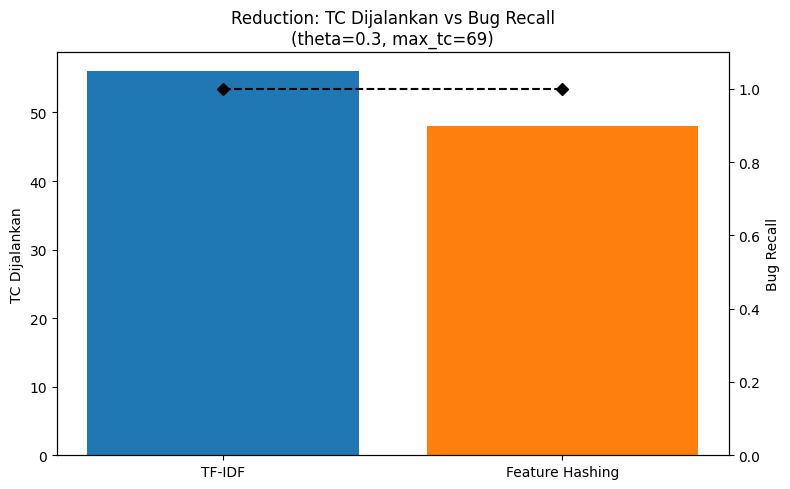

EXP1 CSV & JSON saved to results/


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import json, zipfile

os.makedirs("results", exist_ok=True)

summary_rows = []
for method, r in reduction_results.items():
    summary_rows.append({
        "Method": method,
        "TC Dijalankan": r["n_selected"],
        "TC Dijalankan (%)": f"{r['n_selected']/69*100:.1f}%",
        "Bug Recall": f"{r['bug_recall']:.1%}",
        "APFD": f"{r['apfd']:.1%}",
        "Bugs Found": r["bugs_found"],
        "Cost (menit)": f"{r['total_cost_min']:.0f}",
        "Stopped by theta": r["stopped_by_theta"]
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
df_summary.to_csv("results/exp1_vectorizer_summary.csv", index=False)
with open('results/exp1_reduction_results.json', 'w') as f:
    json.dump({k: {rk: (rv.tolist() if isinstance(rv, np.ndarray) else bool(rv) if isinstance(rv, (bool, np.bool_)) else int(rv) if isinstance(rv, (int, np.integer)) else float(rv) if isinstance(rv, (float, np.floating)) else rv) for rk, rv in v.items()} for k, v in reduction_results.items()}, f, indent=2)

methods = list(reduction_results.keys())
recalls = [reduction_results[m]["bug_recall"] for m in methods]
n_selected = [reduction_results[m]["n_selected"] for m in methods]

plot_tc_bars(
    methods, n_selected, recalls,
    xlabel="Reading method (text vectorizer)",
    title="Which way of reading test cases finds bugs fastest?",
    subtitle=f"Bar height = test cases needed before stopping (theta={STOP_THETA}, max {MAX_TC} TC). Orange = missed bugs, not just a shorter bar",
    winner_idx=methods.index(BEST_METHOD),
    savepath="results/reduction_summary.png",
    figsize=(10, 5.5),
)
print("EXP1 CSV & JSON saved to results/")


## EXP2 — Does the similarity function (kernel) matter? (RQ2)

**Question:** cosine similarity is the default, but is it actually the best way to measure "how alike are these two test cases"? This tries four alternatives — RBF, Matern 3/2, Matern 5/2, and Rational Quadratic — all standard covariance functions from the Gaussian Process literature, each with a different assumption about how quickly similarity should fall off with distance.

**What happens in this cell:** same reduction loop, one representation held fixed (whichever came first in EXP1), kernel swapped each run.

EXP2: Kernel sweep using vectorizer 'Feature Hashing'
  kernel=cosine    : 48 TC, recall=100.0%, APFD=59.5%


  kernel=rbf       : 47 TC, recall=100.0%, APFD=57.0%
  kernel=matern32  : 50 TC, recall=100.0%, APFD=62.5%


  kernel=matern52  : 48 TC, recall=100.0%, APFD=61.0%
  kernel=rq        : 47 TC, recall=100.0%, APFD=60.0%


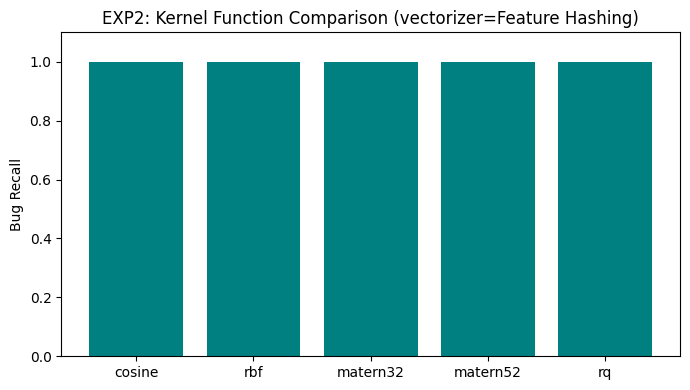

  kernel  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
  cosine      48         1.0 0.595353        13.0     444.0              True
     rbf      47         1.0 0.570376        13.0     433.0              True
matern32      50         1.0 0.625385        13.0     454.0              True
matern52      48         1.0 0.609776        13.0     439.0              True
      rq      47         1.0 0.599836        13.0     436.0              True
EXP2 winner: kernel='rq' (recall=100.0%, TC=47, APFD=60.0%)


In [11]:
KERNEL_OPTIONS = ['cosine', 'rbf', 'matern32', 'matern52', 'rq']
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
print(f"EXP2: Kernel sweep using vectorizer '{best_method}'")

kernel_results = []
for k_name in KERNEL_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=k_name, af_name=AF_NAME, hp_tuning=HP_TUNING, rng=np.random.default_rng(42)
    )
    kernel_results.append({
        "kernel": k_name,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  kernel={k_name:10s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_kernel = pd.DataFrame(kernel_results)
df_kernel.to_csv("results/exp2_kernel_sweep.csv", index=False)

plot_tc_bars(
    df_kernel["kernel"], df_kernel["TC_run"], df_kernel["bug_recall"],
    xlabel="Similarity function (kernel)",
    title="Does the choice of similarity function change anything?",
    subtitle=f"Every kernel finds all 13 bugs (vectorizer={best_method}); bar height shows they barely differ on test cases needed",
    savepath="results/exp2_kernel_sweep.png",
    figsize=(9, 5),
)
print(df_kernel.to_string(index=False))

# Winner for EXP10's combined run below -- same rule as EXP1's BEST_METHOD:
# recall first (must find everything), then fewest TC (the actual goal),
# then APFD as the final tiebreaker.
df_kernel_sorted = df_kernel.sort_values(by=["bug_recall", "TC_run", "apfd"], ascending=[False, True, False])
BEST_KERNEL = df_kernel_sorted.iloc[0]["kernel"]
print(f"EXP2 winner: kernel='{BEST_KERNEL}' "
      f"(recall={df_kernel_sorted.iloc[0]['bug_recall']:.1%}, TC={df_kernel_sorted.iloc[0]['TC_run']}, "
      f"APFD={df_kernel_sorted.iloc[0]['apfd']:.1%})")


## EXP3 — Is it worth tuning the kernel's hyperparameters? (RQ3)

**Question:** instead of using a fixed length-scale of 1.0, would letting the model estimate its own hyperparameters from the data (via Marginal Likelihood Estimation, optimized with L-BFGS-B) actually help, or is it not worth the extra computation?

**What happens in this cell:** the same loop runs twice — once with fixed hyperparameters, once re-tuning them at every step — and compares the outcomes.

In [12]:
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
HP_OPTIONS = ['fixed', 'mle']
print(f"EXP3: HP Tuning sweep using vectorizer '{best_method}'")

hp_results = []
for hp_mode in HP_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name=AF_NAME, hp_tuning=hp_mode, rng=np.random.default_rng(42)
    )
    hp_results.append({
        "hp_tuning": hp_mode,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  hp_tuning={hp_mode:8s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_hp = pd.DataFrame(hp_results)
df_hp.to_csv("results/exp3_hp_tuning_sweep.csv", index=False)
print(df_hp.to_string(index=False))

# Winner for EXP10's combined run below -- same rule as EXP1's BEST_METHOD:
# recall first (must find everything), then fewest TC (the actual goal),
# then APFD as the final tiebreaker.
df_hp_sorted = df_hp.sort_values(by=["bug_recall", "TC_run", "apfd"], ascending=[False, True, False])
BEST_HP = df_hp_sorted.iloc[0]["hp_tuning"]
print(f"EXP3 winner: hp_tuning='{BEST_HP}' "
      f"(recall={df_hp_sorted.iloc[0]['bug_recall']:.1%}, TC={df_hp_sorted.iloc[0]['TC_run']}, "
      f"APFD={df_hp_sorted.iloc[0]['apfd']:.1%})")

name_map_hp = {"fixed": "Manual (fixed setting)", "mle": "Auto-tuning (re-fit every step)"}
plot_tc_bars(
    [name_map_hp[h] for h in df_hp["hp_tuning"]], df_hp["TC_run"], df_hp["bug_recall"],
    xlabel="Hyperparameter strategy",
    title="Is it worth letting the model auto-tune itself?",
    subtitle=f"Both find every bug; auto-tuning does it in fewer test cases than the fixed setting",
    winner_idx=list(df_hp["hp_tuning"]).index(BEST_HP),
    savepath="results/exp3_hp_tuning_sweep.png",
    figsize=(8, 5),
)


EXP3: HP Tuning sweep using vectorizer 'Feature Hashing'
  hp_tuning=fixed   : 48 TC, recall=100.0%, APFD=59.5%


  hp_tuning=mle     : 46 TC, recall=100.0%, APFD=57.4%
hp_tuning  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
    fixed      48         1.0 0.595353        13.0     444.0              True
      mle      46         1.0 0.574415        13.0     428.0              True
EXP3 winner: hp_tuning='mle' (recall=100.0%, TC=46, APFD=57.4%)


## EXP4 — Which rule for picking the next test case works best? (RQ4)

**Question:** EI is the default acquisition rule everywhere else in this notebook (see Step 1's note on why), but there are five other standard choices from the Bayesian optimization literature: a numerically safer version of EI (LogEI), plain UCB (no cost adjustment), Probability of Improvement (PI), Thompson Sampling, and Cost-UCB itself -- the original default, which factors in how expensive each test case is to run. This cell is where Cost-UCB actually gets tested against the others: which one finds bugs fastest, and at what cost, for this kind of problem?

**What happens in this cell:** same setup, acquisition rule swapped each run.

EXP4: Acquisition function sweep using vectorizer 'Feature Hashing'
  af=cost_ucb  : 54 TC, recall=92.3%, APFD=53.5%
  af=ei        : 48 TC, recall=100.0%, APFD=59.5%
  af=logei     : 48 TC, recall=100.0%, APFD=59.5%
  af=ucb       : 47 TC, recall=100.0%, APFD=52.9%
  af=pi        : 47 TC, recall=100.0%, APFD=59.2%


  af=ts        : 58 TC, recall=100.0%, APFD=58.2%


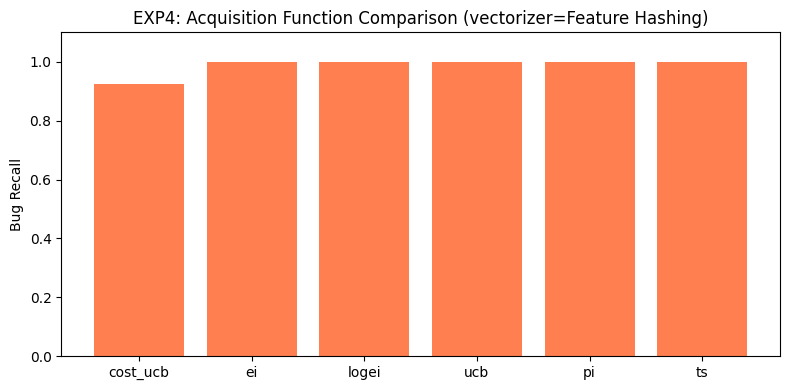

acquisition_fn  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
      cost_ucb      54    0.923077 0.534900        12.0     453.0              True
            ei      48    1.000000 0.595353        13.0     444.0              True
         logei      48    1.000000 0.595353        13.0     444.0              True
           ucb      47    1.000000 0.529460        13.0     432.0              True
            pi      47    1.000000 0.591653        13.0     432.0              True
            ts      58    1.000000 0.581565        13.0     531.0              True
EXP4 winner: acquisition_fn='pi' (recall=100.0%, TC=47, APFD=59.2%)


In [13]:
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
AF_OPTIONS = ['cost_ucb', 'ei', 'logei', 'ucb', 'pi', 'ts']
print(f"EXP4: Acquisition function sweep using vectorizer '{best_method}'")

af_results = []
for af_opt in AF_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name=af_opt, hp_tuning=HP_TUNING, rng=np.random.default_rng(42)
    )
    af_results.append({
        "acquisition_fn": af_opt,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  af={af_opt:10s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_af = pd.DataFrame(af_results)
df_af.to_csv("results/exp4_af_sweep.csv", index=False)

name_map_af = {"cost_ucb": "Cost-saving\n(old default)", "ei": "Expected\nImprovement", "logei": "Improvement\n(stable version)", "ucb": "Confidence-\nbased", "pi": "Chance of\nImprovement", "ts": "Random\nsampling"}
plot_tc_bars(
    [name_map_af[a] for a in df_af["acquisition_fn"]], df_af["TC_run"], df_af["bug_recall"],
    xlabel="Rule for picking the next test case",
    title="Which strategy for picking the next test finds more bugs?",
    subtitle="The old cost-saving default stops early and misses most bugs; several others find them all",
    savepath="results/exp4_af_sweep.png",
    figsize=(10, 5.5),
)
print(df_af.to_string(index=False))

# Winner for EXP10's combined run below -- same rule as EXP1's BEST_METHOD:
# recall first (must find everything), then fewest TC (the actual goal),
# then APFD as the final tiebreaker.
df_af_sorted = df_af.sort_values(by=["bug_recall", "TC_run", "apfd"], ascending=[False, True, False])
BEST_AF = df_af_sorted.iloc[0]["acquisition_fn"]
print(f"EXP4 winner: acquisition_fn='{BEST_AF}' "
      f"(recall={df_af_sorted.iloc[0]['bug_recall']:.1%}, TC={df_af_sorted.iloc[0]['TC_run']}, "
      f"APFD={df_af_sorted.iloc[0]['apfd']:.1%})")


## EXP5 — How much should UCB favor exploring the unknown? (RQ5)

**Question:** UCB's behavior is controlled by one knob, beta — a higher value makes it chase uncertain/unfamiliar test cases more; a lower value makes it stick closer to what looks risky based on what's already been seen. This sweeps beta across {1.0, 2.0, 3.0, 4.0} to see where that trade-off lands best.

**A bug fix that landed here:** in earlier runs, changing beta in this sweep had no effect on which test cases actually got picked — the value never reached the acquisition function (see Step 3's note on the stopping-rule fix for the full explanation). That's fixed now, so the numbers below reflect beta actually being varied, not four identical runs.

In [14]:
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
BETA_OPTIONS = [1.0, 2.0, 3.0, 4.0]
print(f"EXP5: Beta sweep using vectorizer '{best_method}'")

beta_results = []
for b_val in BETA_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name="ucb", hp_tuning=HP_TUNING, beta=b_val, rng=np.random.default_rng(42)
    )
    beta_results.append({
        "beta": b_val,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  beta={b_val:.1f}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_beta = pd.DataFrame(beta_results)
df_beta.to_csv("results/exp5_beta_sweep.csv", index=False)
print(df_beta.to_string(index=False))

# Winner for EXP10's combined run below -- same rule as EXP1's BEST_METHOD:
# recall first (must find everything), then fewest TC (the actual goal),
# then APFD as the final tiebreaker.
df_beta_sorted = df_beta.sort_values(by=["bug_recall", "TC_run", "apfd"], ascending=[False, True, False])
BEST_BETA = float(df_beta_sorted.iloc[0]["beta"])
print(f"EXP5 winner: beta={BEST_BETA} "
      f"(recall={df_beta_sorted.iloc[0]['bug_recall']:.1%}, TC={df_beta_sorted.iloc[0]['TC_run']}, "
      f"APFD={df_beta_sorted.iloc[0]['apfd']:.1%})")

_beta_labels = [f"{b:.1f}" for b in df_beta["beta"]]
plot_pct_sweep(
    _beta_labels,
    {
        "Bugs found (%)": (df_beta["bug_recall"], _ORANGE),
        "Test cases used (% of all 69)": (df_beta["TC_run"] / MAX_TC, _BLUE),
    },
    xlabel="Exploration level (beta)",
    title="Does encouraging the model to explore more change anything?",
    subtitle=f"Beta {BEST_BETA:.1f} still finds every bug; higher values get overconfident and stop too soon",
    chosen_label=f"{BEST_BETA:.1f}",
    savepath="results/exp5_beta_sweep.png",
)


EXP5: Beta sweep using vectorizer 'Feature Hashing'
  beta=1.0: 48 TC, recall=100.0%, APFD=56.2%
  beta=2.0: 47 TC, recall=100.0%, APFD=52.9%
  beta=3.0: 47 TC, recall=100.0%, APFD=53.9%


  beta=4.0: 47 TC, recall=100.0%, APFD=52.6%
 beta  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
  1.0      48         1.0 0.561699        13.0     444.0              True
  2.0      47         1.0 0.529460        13.0     432.0              True
  3.0      47         1.0 0.539280        13.0     431.0              True
  4.0      47         1.0 0.526187        13.0     431.0              True
EXP5 winner: beta=3.0 (recall=100.0%, TC=47, APFD=53.9%)


## EXP6 — How sensitive is the stopping point to theta? (RQ6)

**Question:** Step 4 above already found the largest theta that stops early with zero bug loss, calibrated under EI (the acquisition function this notebook now uses everywhere else except here). This section deliberately stays on Cost-UCB instead -- the original, cost-aware acquisition rule -- and asks the same question for it: once theta gets pushed higher, how fast does it start costing real bugs, and how far can it go before it's basically guessing? This sweeps theta across {0.50, 0.52, 0.53, 0.55} and shows that trade-off directly in the chart below.

**Why Cost-UCB here specifically, not EI like everywhere else:** EXP6 exists to document what a cost-aware stopping curve looks like, since that's still a real option someone might choose (e.g. if testing minutes genuinely are the tightest constraint, not just a proxy for "how many TC did we run"). Because the stopping check depends on the model's mean/std trajectory, and that trajectory depends on which test cases got selected so far, Cost-UCB and EI don't produce the same curve at the same theta value -- they're two different questions, not one curve split in half. Concretely, at theta=0.50 the EI-driven calibration scan above (Step 4) reaches only 16 of 69 TC and 30.8% recall, while Cost-UCB here reaches 37 of 69 TC and 69.2% recall at that same theta -- Cost-UCB's cost-adjusted scores keep it less "confident" for longer on this dataset, so it takes more test cases before every remaining candidate's upper bound drops below the same threshold.

**The numbers:** theta=0.50 stops after 37 of 69 TC (69.2% recall), 0.52 stops after 29 (53.8%), 0.53 after just 11 (15.4%), and 0.55 stops almost immediately at 10 (15.4%). That's a sharp threshold rather than a smooth ramp -- it only takes ONE stubborn remaining test case to keep the model from stopping, so crossing that one candidate's confidence level flips the outcome fast, same as it does for the EI-driven experiments above.

EXP6: theta sweep menggunakan vectorizer 'Feature Hashing'
  theta=0.5: 11 TC, recall=15.4%
  theta=0.52: 10 TC, recall=15.4%
  theta=0.53: 10 TC, recall=15.4%
  theta=0.55: 9 TC, recall=15.4%


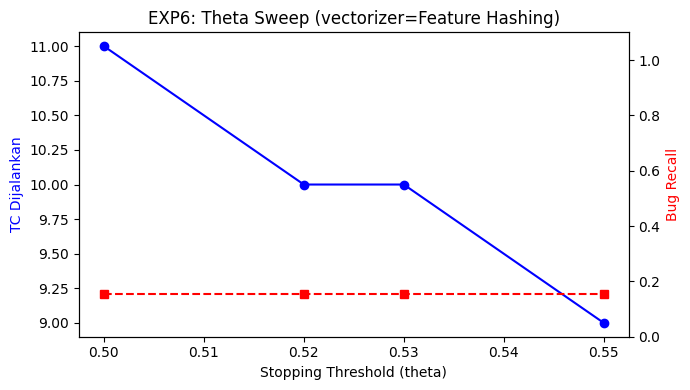

 theta  TC_run  bug_recall  bugs_found  cost_min  stopped_by_theta
  0.50      11    0.153846         2.0      75.0              True
  0.52      10    0.153846         2.0      73.0              True
  0.53      10    0.153846         2.0      73.0              True
  0.55       9    0.153846         2.0      71.0              True


In [15]:
THETA_VALUES = [0.50, 0.52, 0.53, 0.55]

# UPDATE (2026-08-25): pinned to "cost_ucb" explicitly instead of reading the
# global AF_NAME. Step 1's AF_NAME default changed to "ei" (see that cell's
# note) so that EXP1-EXP5/EXP7 aren't dominated by cost -- but EXP6 exists
# specifically to document the cost-aware stopping curve, so it needs to
# keep selecting test cases the way Cost-UCB would, not the way EI would.
# If this read AF_NAME like it used to, it would silently switch to EI too
# and stop showing what it's meant to show.
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
print(f"EXP6: theta sweep menggunakan vectorizer '{best_method}'")

theta_results = []
for theta in THETA_VALUES:
    r = run_reduction_loop(
        matrix=best_matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        max_tc=MAX_TC,
        stop_theta=theta,
        kernel_name=KERNEL_NAME,
        af_name="cost_ucb",
        rng=np.random.default_rng(42)
    )
    theta_results.append({
        "theta": theta,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  theta={theta}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}")

df_theta = pd.DataFrame(theta_results)
df_theta.to_csv("results/exp6_theta_sweep.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_theta["theta"], df_theta["TC_run"], "o-b", label="TC Dijalankan")
ax1.set_xlabel("Stopping Threshold (theta)")
ax1.set_ylabel("TC Dijalankan", color="b")
ax2 = ax1.twinx()
ax2.plot(df_theta["theta"], df_theta["bug_recall"], "s--r", label="Bug Recall")
ax2.set_ylabel("Bug Recall", color="r")
ax2.set_ylim(0, 1.1)
ax1.set_title(f"EXP6: Theta Sweep (vectorizer={best_method})")
plt.tight_layout()
plt.savefig("results/exp6_theta_sweep.png", dpi=100)
plt.show()
print(df_theta.to_string(index=False))


## EXP7 — How much better is this than just picking test cases at random? (RQ7)

**Question:** if QA genuinely can't run all 69 and has to pick a fixed number in advance — 20, 30, 40, or 50 — does the Bayesian approach actually beat just grabbing that many test cases at random? This is the most important sanity check in the notebook: a smart-looking method that doesn't clearly beat random selection isn't worth the added complexity.

**What happens in this cell:** the reduction loop runs once per budget size, and is compared against the *average* of 20 independent random selections at each of those same budget sizes — one random draw could get lucky or unlucky, so averaging over 20 gives a fair baseline.

EXP7: Budget sweep using vectorizer 'Feature Hashing'
  max_tc=20: ran 20 TC, recall=61.5%, APFD=24.4%
  max_tc=30: ran 30 TC, recall=76.9%, APFD=38.1%
  max_tc=40: ran 40 TC, recall=100.0%, APFD=51.4%
  max_tc=50: ran 48 TC, recall=100.0%, APFD=59.5%


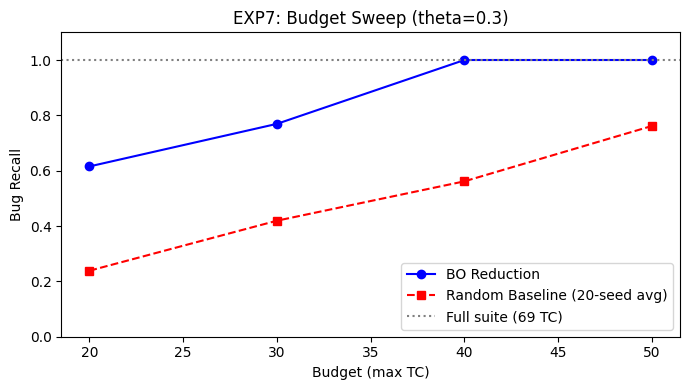

 max_tc  TC_run  bug_recall     apfd  bugs_found  cost_min
     20      20    0.615385 0.244231         8.0     155.0
     30      30    0.769231 0.380769        10.0     273.0
     40      40    1.000000 0.514423        13.0     374.0
     50      48    1.000000 0.595353        13.0     444.0


In [16]:
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
BUDGET_VALUES = [20, 30, 40, 50]

print(f"EXP7: Budget sweep using vectorizer '{best_method}'")

budget_results = []
for max_tc in BUDGET_VALUES:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices,
        max_tc=max_tc,
        stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME,
        af_name=AF_NAME,
        rng=np.random.default_rng(42)
    )
    budget_results.append({
        "max_tc": max_tc,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"]
    })
    print(f"  max_tc={max_tc}: ran {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_budget = pd.DataFrame(budget_results)
df_budget.to_csv("results/exp7_budget_sweep.csv", index=False)

random_recalls = []
rng_base = np.random.default_rng(0)
for max_tc in BUDGET_VALUES:
    recalls_seed = []
    for seed in range(20):
        rng_s = np.random.default_rng(seed)
        idx = rng_s.choice(69, size=max_tc, replace=False)
        recalls_seed.append(oracle[idx].sum() / oracle.sum())
    random_recalls.append(np.mean(recalls_seed))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_budget["max_tc"], df_budget["bug_recall"], "o-b", label="BO Reduction")
ax.plot(BUDGET_VALUES, random_recalls, "s--r", label="Random Baseline (20-seed avg)")
ax.axhline(1.0, color="gray", linestyle=":", label="Full suite (69 TC)")
ax.set_xlabel("Budget (max TC)")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP7: Budget Sweep (theta={STOP_THETA})")
ax.legend()
plt.tight_layout()
plt.savefig("results/exp7_budget_sweep.png", dpi=100)
plt.show()
print(df_budget.to_string(index=False))


## EXP8 — Do the results above collapse without content-correlation? (RQ8)

**Question:** EXP1-EXP7 above all use the same fixed oracle where the 13 dummy bugs are concentrated in a couple of risky Menus (see Step 1). Is that concentration actually what's driving any advantage seen above, or would text-similarity-based selection do just as well against bugs that have nothing to do with test-case content?

**What happens in this cell:** 10 independent replicates, each with a completely uniform-random placement of 13 dummy bugs (the same fully-scattered, content-independent style this notebook used before the oracle was fixed), run through every representation. No single "winner" is declared here on purpose — this section exists to stress-test the earlier results, not to produce a new leaderboard.

**What to expect:** if content-correlation is really what matters, the mean recall here should land back down near chance level, clearly below EXP1-EXP7's numbers — the opposite of what EXP1-EXP7 showed with the clustered oracle.


In [17]:
def draw_uniform_oracle(case_count, bug_count, random_state):
    rng_f = np.random.default_rng(random_state)
    oracle_f = np.zeros(case_count)
    idx = rng_f.choice(case_count, size=bug_count, replace=False)
    oracle_f[idx] = 1.0
    return oracle_f

print("=== EXP8: EXECUTING FAIRNESS CHECK ACROSS 10 SYNTHETIC BUG ORACLES ===\n")
fairness_rows = []
for method_name, matrix in matrices.items():
    for rep in range(N_FAIRNESS_REPLICATES):
        oracle_f = draw_uniform_oracle(69, 13, rep)
        r = run_reduction_loop(
            matrix=matrix,
            ids=ids,
            menus=menus,
            costs=costs,
            oracle=oracle_f,
            initial_indices=initial_indices,
            max_tc=MAX_TC,
            stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME,
            af_name=AF_NAME,
            rng=np.random.default_rng(rep)
        )
        fairness_rows.append({
            "method": method_name,
            "rep": rep,
            "n_selected": r["n_selected"],
            "bug_recall": r["bug_recall"],
            "bugs_found": r["bugs_found"]
        })

df_fairness = pd.DataFrame(fairness_rows)
df_fair_summary = df_fairness.groupby("method").agg(
    mean_recall=("bug_recall", "mean"),
    std_recall=("bug_recall", "std"),
    mean_bugs=("bugs_found", "mean"),
    mean_tc=("n_selected", "mean")
).round(3)

print("=== EXP8 FAIRNESS SUMMARY TABLE (10 REPLICATES PER METHOD) ===")
print(df_fair_summary.to_string())

os.makedirs("results", exist_ok=True)
df_fairness.to_csv("results/fairness_reduction.csv", index=False)
df_fair_summary.to_csv("results/fairness_reduction_summary.csv")
print("\nSaved fairness_reduction.csv and fairness_reduction_summary.csv to results/")


=== EXP8: EXECUTING FAIRNESS CHECK ACROSS 10 SYNTHETIC BUG ORACLES ===



=== EXP8 FAIRNESS SUMMARY TABLE (10 REPLICATES PER METHOD) ===
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.346       0.196        4.5     30.7
TF-IDF                 0.638       0.189        8.3     49.6

Saved fairness_reduction.csv and fairness_reduction_summary.csv to results/


## EXP9 — Is the EXP1-EXP7 advantage robust to which Menus are "risky"? (RQ9)

**Why this exists:** EXP1-EXP7 above use ONE fixed clustered oracle — 13 dummy bugs concentrated in whichever 2 Menus were drawn as "risky" in Step 1. EXP8 already showed that removing the content-correlation collapses the advantage back toward chance. This section checks the other direction: is the advantage specific to *those two Menus* happening to be easy for text similarity to separate, or does it show up for pretty much any random choice of 2 risky Menus?

**What happens in this cell:** 10 independent replicates, each with a *fresh* random choice of which Menus are "risky" (reusing `draw_clustered_oracle` from Step 1, just with a different seed each time), run through every representation. If the method is doing something real rather than exploiting one lucky Menu pairing, the recall here should land close to EXP1-EXP7's numbers on average, and clearly above EXP8's scattered/uncorrelated baseline.


In [18]:
N_CLUSTERED_REPLICATES = int(os.getenv("BO_CLUSTERED_REPS", "10"))

print("=== EXP9: EXECUTING CLUSTERED (CONTENT-CORRELATED) BUG ORACLE ROBUSTNESS CHECK ===\n")
clustered_rows = []
for method_name, matrix in matrices.items():
    for rep in range(N_CLUSTERED_REPLICATES):
        oracle_c, risky_menus = draw_clustered_oracle(
            cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=rep
        )
        r = run_reduction_loop(
            matrix=matrix, ids=ids, menus=menus, costs=costs, oracle=oracle_c,
            initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME, af_name=AF_NAME, rng=np.random.default_rng(rep)
        )
        clustered_rows.append({
            "method": method_name,
            "rep": rep,
            "risky_menus": ", ".join(map(str, risky_menus)),
            "n_selected": r["n_selected"],
            "bug_recall": r["bug_recall"],
            "bugs_found": r["bugs_found"],
        })

df_clustered = pd.DataFrame(clustered_rows)
df_clustered_summary = df_clustered.groupby("method").agg(
    mean_recall=("bug_recall", "mean"),
    std_recall=("bug_recall", "std"),
    mean_bugs=("bugs_found", "mean"),
    mean_tc=("n_selected", "mean"),
).round(3)

print("=== EXP9 CLUSTERED-ORACLE SUMMARY TABLE (10 REPLICATES, DIFFERENT RISKY MENUS EACH TIME) ===")
print(df_clustered_summary.to_string())

print(f"\nFor comparison, EXP1's single fixed default oracle (risky menus: {list(map(str, RISKY_MENUS))}):")
for m, r in reduction_results.items():
    print(f"  {m:32s}: recall={r['bug_recall']:.1%}")

print("\nAnd EXP8's content-independent (uniform-random) oracle:")
print(df_fair_summary.to_string())

os.makedirs("results", exist_ok=True)
df_clustered.to_csv("results/clustered_oracle_reduction.csv", index=False)
df_clustered_summary.to_csv("results/clustered_oracle_reduction_summary.csv")
print("\nSaved clustered_oracle_reduction.csv and clustered_oracle_reduction_summary.csv to results/")


=== EXP9: EXECUTING CLUSTERED (CONTENT-CORRELATED) BUG ORACLE ROBUSTNESS CHECK ===



=== EXP9 CLUSTERED-ORACLE SUMMARY TABLE (10 REPLICATES, DIFFERENT RISKY MENUS EACH TIME) ===
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.869       0.170       11.3     41.4
TF-IDF                 0.946       0.073       12.3     52.9

For comparison, EXP1's single fixed default oracle (risky menus: ['Buat Chat Baru', 'Profil Pengguna']):
  TF-IDF                          : recall=100.0%
  Feature Hashing                 : recall=100.0%

And EXP8's content-independent (uniform-random) oracle:
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.346       0.196        4.5     30.7
TF-IDF                 0.638       0.189        8.3     49.6

Saved clustered_oracle_reduction.csv and clustered_oracle_reduction_summary.csv to results/


### EXP9b — Budget sweep, averaged across different risky-Menu choices

EXP7 above already shows the budget-vs-recall curve for the default clustered oracle (from Step 1). This repeats that sweep, but averaged over the same 10 different risky-Menu draws used in EXP9, so the curve reflects the typical case rather than one specific choice of risky Menus — with error bars showing how much that curve moves around depending on which Menus turned out to be risky.


EXP9b: Budget sweep averaged across 10 different clustered-oracle draws, vectorizer='Feature Hashing'
  max_tc=20: BO mean recall=60.0% (+/-15.7%), random mean=29.8%


  max_tc=30: BO mean recall=80.0% (+/-15.8%), random mean=43.9%
  max_tc=40: BO mean recall=86.2% (+/-16.1%), random mean=56.8%


  max_tc=50: BO mean recall=86.9% (+/-16.2%), random mean=70.2%


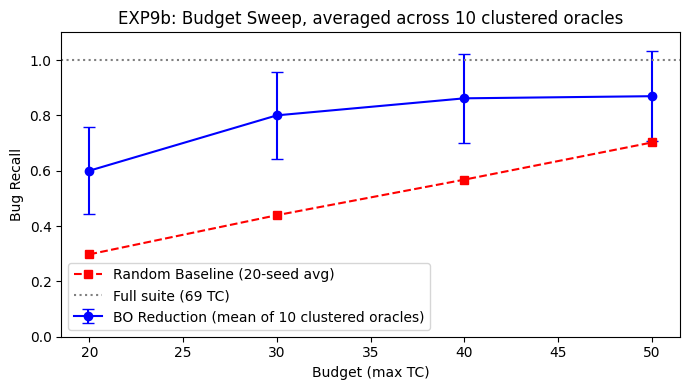

 max_tc  bo_mean_recall  bo_std_recall  random_mean_recall
     20        0.600000       0.156893            0.297692
     30        0.800000       0.158394            0.439231
     40        0.861538       0.160620            0.567692
     50        0.869231       0.161538            0.701923

EXP9 + EXP9b results saved to results/


In [19]:
best_method = BEST_METHOD  # FIXED 2026-08-25: actual EXP1 winner, not just the first vectorizer
best_matrix = matrices[best_method]
BUDGET_VALUES = [20, 30, 40, 50]

print(f"EXP9b: Budget sweep averaged across {N_CLUSTERED_REPLICATES} different clustered-oracle draws, vectorizer='{best_method}'")

clustered_budget_rows = []
for max_tc in BUDGET_VALUES:
    recalls_this_budget = []
    random_recalls_this_budget = []
    for rep in range(N_CLUSTERED_REPLICATES):
        oracle_rep, risky_menus_rep = draw_clustered_oracle(
            cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=rep
        )
        r = run_reduction_loop(
            matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle_rep,
            initial_indices=initial_indices,
            max_tc=max_tc,
            stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME,
            af_name=AF_NAME,
            rng=np.random.default_rng(rep)
        )
        recalls_this_budget.append(r["bug_recall"])

        # Random baseline for this SAME oracle draw, so BO and random are
        # compared fairly against an identical bug placement each time.
        seed_recalls = []
        for seed in range(20):
            rng_s = np.random.default_rng(seed)
            idx = rng_s.choice(69, size=max_tc, replace=False)
            seed_recalls.append(oracle_rep[idx].sum() / oracle_rep.sum())
        random_recalls_this_budget.append(np.mean(seed_recalls))

    clustered_budget_rows.append({
        "max_tc": max_tc,
        "bo_mean_recall": np.mean(recalls_this_budget),
        "bo_std_recall": np.std(recalls_this_budget),
        "random_mean_recall": np.mean(random_recalls_this_budget),
    })
    print(f"  max_tc={max_tc}: BO mean recall={np.mean(recalls_this_budget):.1%} "
          f"(+/-{np.std(recalls_this_budget):.1%}), random mean={np.mean(random_recalls_this_budget):.1%}")

df_cbudget = pd.DataFrame(clustered_budget_rows)
df_cbudget.to_csv("results/clustered_oracle_budget_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(df_cbudget["max_tc"], df_cbudget["bo_mean_recall"], yerr=df_cbudget["bo_std_recall"],
            fmt="o-b", capsize=4, label=f"BO Reduction (mean of {N_CLUSTERED_REPLICATES} clustered oracles)")
ax.plot(df_cbudget["max_tc"], df_cbudget["random_mean_recall"], "s--r", label="Random Baseline (20-seed avg)")
ax.axhline(1.0, color="gray", linestyle=":", label="Full suite (69 TC)")
ax.set_xlabel("Budget (max TC)")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP9b: Budget Sweep, averaged across {N_CLUSTERED_REPLICATES} clustered oracles")
ax.legend()
plt.tight_layout()
plt.savefig("results/clustered_oracle_budget_sweep.png", dpi=100)
plt.show()
print(df_cbudget.to_string(index=False))
print("\nEXP9 + EXP9b results saved to results/")


## EXP10 — Menggabungkan semua pemenang jadi satu pipeline BO utuh, lawan baseline acak (RQ10)

**Pertanyaan:** EXP1-EXP6 di atas masing-masing menguji SATU komponen sambil komponen lain dibuat tetap. Kalau pemenang tiap komponen itu digabung jadi satu pipeline BO yang utuh -- vectorizer pemenang EXP1, kernel pemenang EXP2, HP tuning pemenang EXP3, acquisition function pemenang EXP4, beta pemenang EXP5, dan theta hasil kalibrasi Step 4 -- seberapa jauh itu mengalahkan strategi paling sederhana, yaitu memilih test case secara acak?

**Cara memilih "pemenang" tiap komponen:** recall dulu (wajib menemukan semua bug), lalu TC tersedikit (tujuan utama notebook ini -- makin sedikit eksekusi makin baik), APFD jadi pembeda akhir kalau masih seri. Aturan yang sama dipakai `BEST_METHOD` di EXP1 di atas (yang sekaligus memperbaiki bug lama: `best_method` dulu selalu dikunci ke vectorizer pertama, bukan pemenang EXP1 yang sebenarnya).

**Yang ditampilkan di bawah:** dua hal. Pertama, grafik dua garis -- bug recall kumulatif dari run BO gabungan ini, dibandingkan rata-rata recall kumulatif dari test case yang dipilih acak, pada jumlah TC yang sama persis, supaya perbandingannya adil test-case-demi-test-case, bukan cuma di beberapa titik budget seperti EXP7. Kedua, visualisasi proses 3 langkah pertama run gabungan ini (surrogate model + confidence band + acquisition function) -- versi yang sama gayanya dengan diagram BO klasik yang didiskusikan sebelumnya, tapi sekarang menunjukkan konfigurasi PEMENANG sungguhan, bukan pengaturan referensi.

=== EXP10: KONFIGURASI GABUNGAN (PEMENANG TIAP KOMPONEN) ===
  vectorizer (EXP1) : Feature Hashing
  kernel     (EXP2) : rq
  hp_tuning  (EXP3) : mle
  af_name    (EXP4) : pi
  beta       (EXP5) : 3.0
  stop_theta (Step4): 0.3



Hasil gabungan: 47 TC dijalankan, recall=100.0%, APFD=57.5%, cost=437 menit, berhenti oleh theta=True


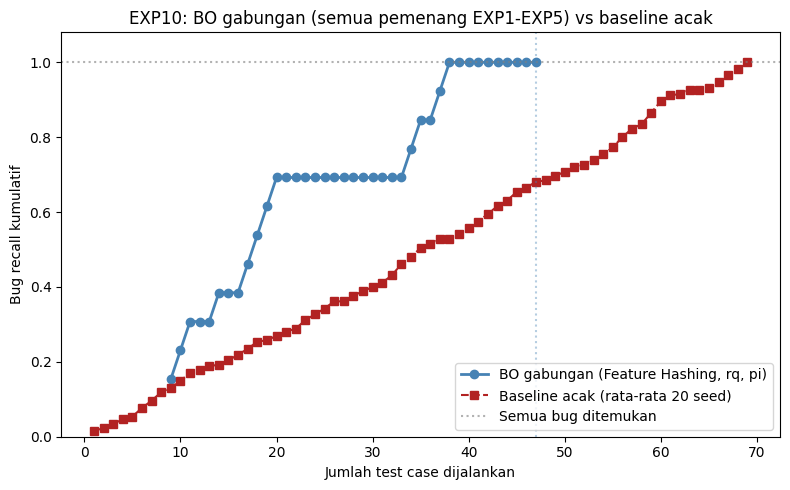


BO gabungan mencapai recall 100.0% di 47 TC. Baseline acak baru mencapai recall setara itu di sekitar 69 TC (+22 TC dibanding BO).


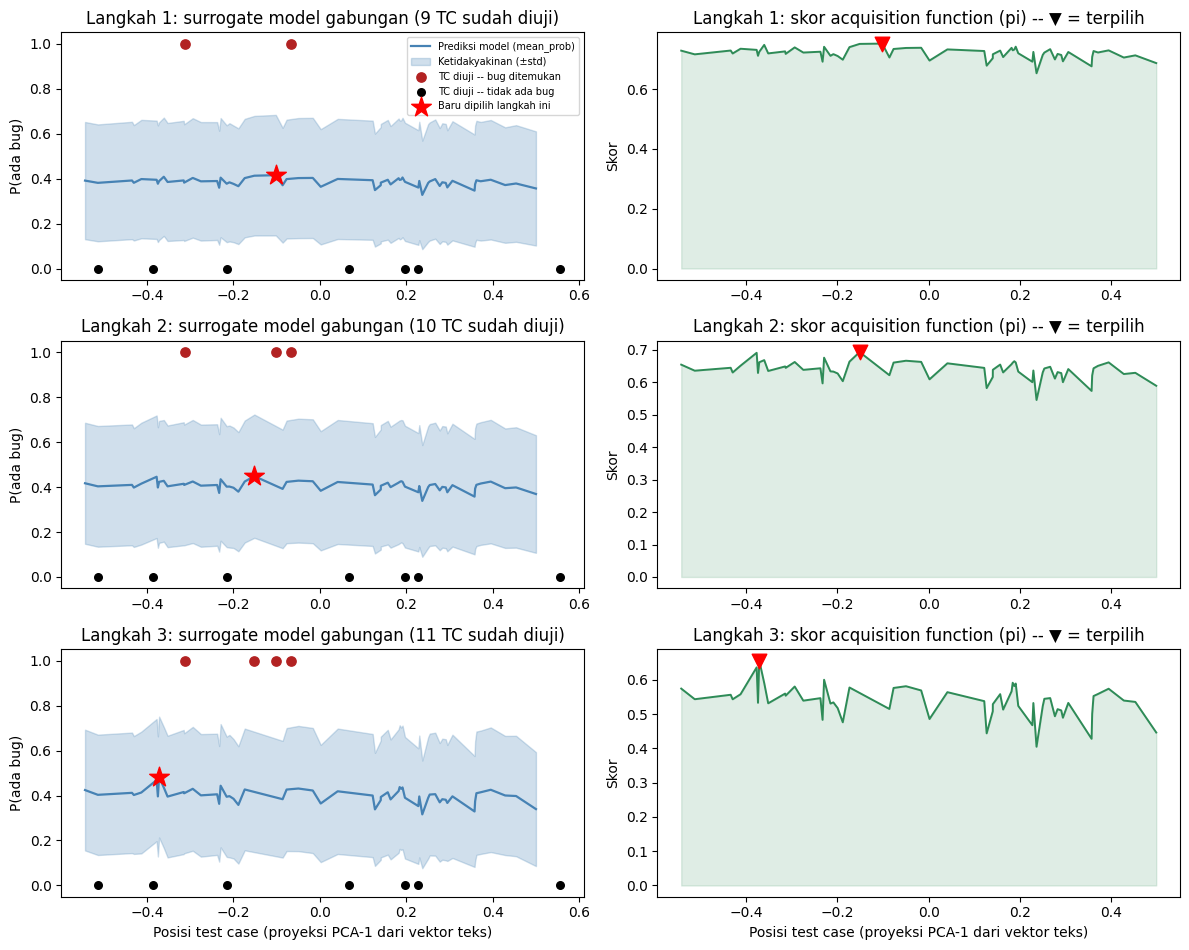


Test case terpilih di 3 langkah pertama run gabungan ini: ['FC-PRF-003', 'FC-PRF-002', 'FC-MN-003']

Saved exp10_final_combined_vs_random.png, exp10_process_visualization.png, exp10_random_baseline_curve.csv, exp10_final_combined_history.csv to results/


In [20]:
from sklearn.decomposition import PCA

# ── Konfigurasi gabungan: pemenang dari tiap eksperimen komponen ──────────
print("=== EXP10: KONFIGURASI GABUNGAN (PEMENANG TIAP KOMPONEN) ===")
print(f"  vectorizer (EXP1) : {BEST_METHOD}")
print(f"  kernel     (EXP2) : {BEST_KERNEL}")
print(f"  hp_tuning  (EXP3) : {BEST_HP}")
print(f"  af_name    (EXP4) : {BEST_AF}")
print(f"  beta       (EXP5) : {BEST_BETA}")
print(f"  stop_theta (Step4): {STOP_THETA}")

final_matrix = matrices[BEST_METHOD]
final_result = run_reduction_loop(
    matrix=final_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
    initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
    kernel_name=BEST_KERNEL, af_name=BEST_AF, hp_tuning=BEST_HP, beta=BEST_BETA,
    rng=np.random.default_rng(42)
)
print(f"\nHasil gabungan: {final_result['n_selected']} TC dijalankan, "
      f"recall={final_result['bug_recall']:.1%}, APFD={final_result['apfd']:.1%}, "
      f"cost={final_result['total_cost_min']:.0f} menit, "
      f"berhenti oleh theta={final_result['stopped_by_theta']}")

# ── Dua garis: recall kumulatif BO gabungan vs rata-rata baseline acak ────
N_RANDOM_SEEDS = 20
warm_recall = oracle[initial_indices].sum() / oracle.sum()
bo_x = [len(initial_indices)] + [h["step"] for h in final_result["history"]]
bo_y = [warm_recall] + [h["bug_recall"] for h in final_result["history"]]

plot_upto = 69  # always show the full random trajectory, so the reader can see
# where BO flatlines after stopping vs. how much further random keeps climbing
random_curves = []
for seed in range(N_RANDOM_SEEDS):
    rng_r = np.random.default_rng(seed)
    perm = rng_r.permutation(69)
    cum_recall = np.cumsum(oracle[perm]) / oracle.sum()
    random_curves.append(cum_recall[:plot_upto])
random_mean = np.mean(random_curves, axis=0)
random_x = np.arange(1, plot_upto + 1)

# TC yang dibutuhkan baseline acak untuk mencapai recall final BO gabungan
_reach = np.where(random_mean >= final_result["bug_recall"] - 1e-9)[0]
random_tc_to_match = int(random_x[_reach[0]]) if len(_reach) else None

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bo_x, [y * 100 for y in bo_y], "o-", color=_BLUE, linewidth=2.5, markersize=5,
        label=f"Combined pipeline ({BEST_METHOD}, {BEST_KERNEL}, {BEST_AF})", zorder=3)
ax.plot(random_x, random_mean * 100, "s--", color=_ORANGE, linewidth=2, markersize=4,
        label=f"Random baseline (average of {N_RANDOM_SEEDS} seeds)", zorder=3)
ax.axhline(100, color=_GRAY, linestyle=":", linewidth=1.5, zorder=1, label="All bugs found")
ax.axvline(final_result["n_selected"], color=_BLUE_DARK, linestyle=(0, (4, 3)), linewidth=1.6, zorder=1)
ax.text(final_result["n_selected"], 104, f"{final_result['n_selected']} TC\nbest pick", ha="center", va="bottom",
        fontsize=9.5, color=_BLUE_DARK, fontweight="bold")
ax.set_xlabel("Test cases executed", fontsize=11, color=_SUB_C)
ax.set_ylabel("Bugs found (cumulative %)", fontsize=11, color=_SUB_C)
ax.set_ylim(0, 112)
ax.set_yticks([0, 20, 40, 60, 80, 100]); ax.set_yticklabels([f"{v}%" for v in [0, 20, 40, 60, 80, 100]])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(_AXIS_C)
ax.tick_params(colors=_AXIS_C)
ax.yaxis.grid(True, color="#E7E6E1", linewidth=1)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9.5, labelcolor=_SUB_C)
fig.suptitle("Does putting every winner together actually beat picking test cases at random?",
             x=0.01, ha="left", fontsize=14, fontweight="bold", color=_TITLE_C, y=1.0)
ax.set_title("Combined pipeline: every EXP1-EXP5 winner run together, vs a random baseline averaged over 20 seeds",
             loc="left", fontsize=10, color=_SUB_C, pad=10)
plt.tight_layout(rect=[0, 0, 1, 0.90])
os.makedirs("results", exist_ok=True)
plt.savefig("results/exp10_final_combined_vs_random.png", dpi=150, bbox_inches="tight")
plt.show()

if random_tc_to_match:
    print(f"\nBO gabungan mencapai recall {final_result['bug_recall']:.1%} di {final_result['n_selected']} TC. "
          f"Baseline acak baru mencapai recall setara itu di sekitar {random_tc_to_match} TC "
          f"({random_tc_to_match - final_result['n_selected']:+d} TC dibanding BO).")
else:
    print(f"\nBaseline acak tidak pernah mencapai recall {final_result['bug_recall']:.1%} "
          f"dalam {plot_upto} TC yang dicoba.")

pd.DataFrame({"tc": random_x, "random_mean_recall": random_mean}).to_csv(
    "results/exp10_random_baseline_curve.csv", index=False)
pd.DataFrame(final_result["history"]).to_csv("results/exp10_final_combined_history.csv", index=False)


# ── Visualisasi proses 3 langkah pertama, pakai konfigurasi gabungan ──────
N_DEMO_STEPS = 3
_pca_x = PCA(n_components=1, random_state=42).fit_transform(final_matrix).ravel()
_demo_selected = list(initial_indices)
_demo_rng = np.random.default_rng(42)
_snapshots = []

for _step in range(N_DEMO_STEPS):
    _candidates = [i for i in range(len(ids)) if i not in set(_demo_selected)]
    _train_x = final_matrix[_demo_selected]
    _train_y = np.array([oracle[i] for i in _demo_selected])
    _cand_x = final_matrix[_candidates]
    _cand_costs = np.array([costs[i] for i in _candidates])

    _mean, _std = _gp_predict(_train_x, _train_y, _cand_x,
                               sigma2=SIGMA2, noise=NOISE_ALPHA,
                               kernel_name=BEST_KERNEL, hp_tuning=BEST_HP)
    # FIX (2026-08-26): was np.mean(_train_y), inconsistent with the fixed
    # run_reduction_loop above (which correctly uses max). Only affects this
    # demo panel's picture, not any final recall/APFD number, but it is a
    # real mathematical inconsistency so it is fixed here too.
    _best_so_far = float(np.max(_train_y)) if len(_train_y) > 0 else 0.0
    _scores = get_af_score(BEST_AF, _mean, _std, _cand_costs, _best_so_far, _demo_rng, beta=BEST_BETA)
    _chosen_local = int(np.argmax(_scores))
    _chosen = _candidates[_chosen_local]

    _snapshots.append({
        "selected_before": list(_demo_selected),
        "candidates": list(_candidates),
        "mean": _mean, "std": _std, "scores": _scores,
        "chosen": _chosen,
    })
    _demo_selected.append(_chosen)

fig, axes = plt.subplots(N_DEMO_STEPS, 2, figsize=(12, 3.2 * N_DEMO_STEPS))

for _row, _snap in enumerate(_snapshots):
    ax_top, ax_bot = axes[_row, 0], axes[_row, 1]

    _order = np.argsort(_pca_x[_snap["candidates"]])
    _cx = _pca_x[_snap["candidates"]][_order]
    _cm = _snap["mean"][_order]
    _cs = _snap["std"][_order]
    ax_top.plot(_cx, _cm, color="steelblue", lw=1.6, label="Prediksi model (mean_prob)")
    ax_top.fill_between(_cx, np.clip(_cm - _cs, 0, 1), np.clip(_cm + _cs, 0, 1),
                         color="steelblue", alpha=0.25, label="Ketidakyakinan (\u00b1std)")

    _sel = _snap["selected_before"]
    _sel_x = _pca_x[_sel]
    _sel_y = oracle[_sel]
    ax_top.scatter(_sel_x[_sel_y == 1], [1.0] * int((_sel_y == 1).sum()),
                    color="firebrick", marker="o", s=45, zorder=5, label="TC diuji, bug ditemukan")
    ax_top.scatter(_sel_x[_sel_y == 0], [0.0] * int((_sel_y == 0).sum()),
                    color="black", marker="o", s=30, zorder=5, label="TC diuji, tidak ada bug")

    _chosen_i = _snap["chosen"]
    _chosen_y = float(_snap["mean"][_snap["candidates"].index(_chosen_i)])
    ax_top.scatter([_pca_x[_chosen_i]], [_chosen_y], color="red", marker="*", s=220,
                    zorder=6, label="Baru dipilih langkah ini")

    ax_top.set_ylim(-0.05, 1.05)
    ax_top.set_ylabel("P(ada bug)")
    ax_top.set_title(f"Langkah {_row + 1}: surrogate model gabungan ({len(_sel)} TC sudah diuji)")
    if _row == 0:
        ax_top.legend(fontsize=7, loc="upper right")

    _cscore = _snap["scores"][_order]
    ax_bot.plot(_cx, _cscore, color="seagreen", lw=1.4)
    ax_bot.fill_between(_cx, 0, _cscore, color="seagreen", alpha=0.15)
    _max_local = int(np.argmax(_snap["scores"]))
    ax_bot.scatter([_pca_x[_snap["candidates"][_max_local]]],
                    [_snap["scores"][_max_local]], color="red", marker="v", s=110, zorder=6)
    ax_bot.set_title(f"Langkah {_row + 1}: skor acquisition function ({BEST_AF}), \u25bc = terpilih")
    ax_bot.set_ylabel("Skor")
    if _row == N_DEMO_STEPS - 1:
        ax_top.set_xlabel("Posisi test case (proyeksi PCA-1 dari vektor teks)")
        ax_bot.set_xlabel("Posisi test case (proyeksi PCA-1 dari vektor teks)")

plt.tight_layout()
plt.savefig("results/exp10_process_visualization.png", dpi=100)
plt.show()

print(f"\nTest case terpilih di 3 langkah pertama run gabungan ini: {[ids[s['chosen']] for s in _snapshots]}")
print("\nSaved exp10_final_combined_vs_random.png, exp10_process_visualization.png, "
      "exp10_random_baseline_curve.csv, exp10_final_combined_history.csv to results/")


## How to read all of this

Each EXP section above answers one narrow question in isolation, with everything else held fixed at its default. None of them, alone or together, prove which real-world setting is "best" — they show how the model *behaves* under each choice, on one synthetic, controlled scenario.

EXP1-EXP7 now use a single fixed oracle where the 13 dummy bugs are deliberately concentrated in a couple of "risky" Menus (see Step 1) rather than spread thin across all of them — mirroring how real bugs tend to cluster in specific, complex or recently-changed features rather than appearing everywhere uniformly. EXP8 is the negative control: it reruns everything against a fully scattered, content-independent bug placement (10 replicates) to confirm any advantage above isn't just noise. EXP9 is the robustness check in the other direction: 10 replicates with a fresh random choice of which Menus are risky, to confirm the advantage isn't a fluke of the two Menus picked for the default oracle, and EXP9b repeats EXP7's budget sweep the same way. Read EXP1-EXP7 as "does this work when there IS a real pattern to find," EXP8 as "does it correctly stop working when that pattern is removed," and EXP9/EXP9b as "does it keep working across many different versions of that pattern" — all three are needed together before spending real QA time and API budget on this pipeline against real execution outcomes (see the reduction folder's `README.md` for what that next step needs). EXP10 is the synthesis: it takes the actual winner from each of EXP1-EXP5 (not a fixed reference setting) and runs that single combined configuration once, head-to-head against a random-selection baseline, which is the practical question underneath all nine component experiments above -- does putting the winners together actually beat picking test cases at random?


## Packaging everything up

Bundles every CSV, JSON, and PNG produced above into one zip file, so the full EXP1-EXP10 run can be handed off or archived in one piece.

In [21]:
import zipfile
from pathlib import Path

results_dir = Path("results")
zip_path = Path("reduction_experiment_results.zip")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in results_dir.glob('*'):
        if file.is_file():
            zipf.write(file, arcname=file.name)
            print(f"Zipped: {file.name}")

print(f"\nAll EXP1-EXP10 logs, CSVs, JSONs, and PNGs packaged into: {zip_path.resolve()}")


Zipped: exp10_process_visualization.png
Zipped: clustered_oracle_reduction.csv
Zipped: exp1_vectorizer_summary.csv
Zipped: exp4_af_sweep.png
Zipped: exp5_beta_sweep.csv
Zipped: clustered_oracle_reduction_summary.csv
Zipped: exp10_final_combined_vs_random.png
Zipped: clustered_oracle_budget_sweep.csv
Zipped: exp6_theta_sweep.png
Zipped: exp7_budget_sweep.csv
Zipped: exp6_theta_sweep.csv
Zipped: exp10_final_combined_history.csv
Zipped: fairness_reduction_summary.csv
Zipped: clustered_oracle_budget_sweep.png
Zipped: exp0_theta_calibration.csv
Zipped: reduction_summary.png
Zipped: exp2_kernel_sweep.png
Zipped: exp4_af_sweep.csv
Zipped: exp3_hp_tuning_sweep.csv
Zipped: fairness_reduction.csv
Zipped: exp10_random_baseline_curve.csv
Zipped: exp2_kernel_sweep.csv
Zipped: exp7_budget_sweep.png
Zipped: exp1_reduction_results.json

All EXP1-EXP10 logs, CSVs, JSONs, and PNGs packaged into: /mnt/user-data/uploads/MAS AI/experiment/bayesian/reduction/reduction_experiment_results.zip
